In [1]:
# use kernel my_e3sm_unified
import numpy as np
import os
os.environ["ESMFMKFILE"]='/global/homes/c/celine/.conda/envs/my_e3sm_unified/lib/esmf.mk'
import xcdat as xc
import xarray as xr
import matplotlib.pyplot as plt
import sys
from eofs.standard import Eof
from eofs.multivariate.standard import MultivariateEof
import scipy 
import genutil
import scipy.stats
#!{sys.executable} -m pip install eofs
#import matplotlib.dates
#from eofs.cdms import Eof
#from matplotlib.ticker import MaxNLocator
#import metpy.calc as mpcalc
#from xarray.coding.times import encode_cf_datetime
print(xc.__version__)

0.8.0


In [2]:
def first_check(fileds,seas):
    print(fileds)
    exept='/global/cfs/projectdirs/m4581/bonfils2/CMIP6/CMIP/past1000/MIROC-ES2L/r1i1p1f2/Amon/rsdt/gn/v20200318/'
    if fileds!=exept: ds = xc.open_mfdataset(fileds+var+'*.nc',add_bounds=('X','Y'),decode_times=True,center_times=True)
    if fileds==exept: ds = xc.open_mfdataset(fileds+var+'*12.nc',add_bounds=('X','Y'),decode_times=True,center_times=True)
    ds.lat.attrs["axis"] = "Y"
    ds.lon.attrs["axis"] = "X"
    print('seas_test',seas)
    if seas=='JJA':
     ds=ds.sel(time=(ds.time.dt.season == "JJA"))
     print(ds.time)
     ds = ds.temporal.group_average(var, freq="season",weighted=True) 
     print(ds)
    if seas=='JAS':
     ds= ds.sel(time=ds.time.dt.month.isin([7, 8, 9]))
     print(ds.time)
     ds = ds.bounds.add_bounds("T") 
     ds = ds.temporal.group_average(var, freq="season",weighted=True,season_config={"custom_seasons": custom_seasons})
     print(ds)
    if seas=='YEAR':
     ds = ds.temporal.group_average(var, freq="year", weighted=True)
    if seas=='JAN':
     ds = ds.sel(time=ds.time.dt.month == 1)
     print(ds.time)
     ds = ds.bounds.add_bounds("T")
     ds = ds.temporal.group_average(var, freq="season",weighted=True,season_config={"custom_seasons": custom_seasons})
    if seas=='FEB':
     ds = ds.sel(time=ds.time.dt.month == 2)
     print(ds.time)
     ds = ds.bounds.add_bounds("T")
     ds = ds.temporal.group_average(var, freq="season",weighted=True,season_config={"custom_seasons": custom_seasons})
    if seas=='MAR':
     ds = ds.sel(time=ds.time.dt.month == 3)
     print(ds.time)
     ds = ds.bounds.add_bounds("T")
     ds = ds.temporal.group_average(var, freq="season",weighted=True,season_config={"custom_seasons": custom_seasons})
    if seas=='APR':
     ds = ds.sel(time=ds.time.dt.month == 4)
     print(ds.time)
     ds = ds.bounds.add_bounds("T")
     ds = ds.temporal.group_average(var, freq="season",weighted=True,season_config={"custom_seasons": custom_seasons})
    if seas=='MAY':
     ds = ds.sel(time=ds.time.dt.month == 5)
     print(ds.time)
     ds = ds.bounds.add_bounds("T")
     ds = ds.temporal.group_average(var, freq="season",weighted=True,season_config={"custom_seasons": custom_seasons})
    if seas=='JUN':
     ds = ds.sel(time=ds.time.dt.month == 6)
     print(ds.time)
     ds = ds.bounds.add_bounds("T")
     ds = ds.temporal.group_average(var, freq="season",weighted=True,season_config={"custom_seasons": custom_seasons})
    if seas=='JUL':
     ds = ds.sel(time=ds.time.dt.month == 7)
     print(ds.time)
     ds = ds.bounds.add_bounds("T")
     ds = ds.temporal.group_average(var, freq="season",weighted=True,season_config={"custom_seasons": custom_seasons})
    if seas=='AUG':
     ds = ds.sel(time=ds.time.dt.month == 8)
     print(ds.time)
     ds = ds.bounds.add_bounds("T")
     ds = ds.temporal.group_average(var, freq="season",weighted=True,season_config={"custom_seasons": custom_seasons})
    if seas=='SEP':
     ds = ds.sel(time=ds.time.dt.month == 9)
     print(ds.time)
     ds = ds.bounds.add_bounds("T")
     ds = ds.temporal.group_average(var, freq="season",weighted=True,season_config={"custom_seasons": custom_seasons})
    if seas=='OCT':
     ds = ds.sel(time=ds.time.dt.month == 10)
     print(ds.time)
     ds = ds.bounds.add_bounds("T")
     ds = ds.temporal.group_average(var, freq="season",weighted=True,season_config={"custom_seasons": custom_seasons})
    if seas=='NOV':
     ds = ds.sel(time=ds.time.dt.month == 11)
     print(ds.time)
     ds = ds.bounds.add_bounds("T")
     ds = ds.temporal.group_average(var, freq="season",weighted=True,season_config={"custom_seasons": custom_seasons})
    if seas=='DEC':
     ds = ds.sel(time=ds.time.dt.month == 12)
     print(ds.time)
     ds = ds.bounds.add_bounds("T")
     ds = ds.temporal.group_average(var, freq="season",weighted=True,season_config={"custom_seasons": custom_seasons})
    weights4 = ds.spatial.get_weights(axis=['Y', 'X'], lat_bounds=[-60,60],lon_bounds=[0,360]) 
    weightsn34 = ds.spatial.get_weights(axis=['Y', 'X'], lat_bounds=[-5,5],lon_bounds=[-170,-120]) 
    weightsnNH = ds.spatial.get_weights(axis=['Y', 'X'],lat_bounds=[0,60],lon_bounds=[0,360]) 
    weightsnSH = ds.spatial.get_weights(axis=['Y', 'X'],lat_bounds=[-60,0],lon_bounds=[0,360]) 
    ts_global = ds.spatial.average(var, axis=["Y", "X"],weights=weights4)[var] 
    ts_n34 = ds.spatial.average(var, axis=["Y", "X"],weights=weightsn34)[var]
    ts_nNH = ds.spatial.average(var, axis=["Y", "X"],weights=weightsnNH)[var]
    ts_nSH = ds.spatial.average(var, axis=["Y", "X"],weights=weightsnSH)[var]
    weights4lon = ds.spatial.get_weights(axis=['X'], lon_bounds=[0,360]) 
    ts_lat = ds.spatial.average(var, axis=["X"],weights=weights4lon)[var] 
    print('gl',ts_global[0].values)
    print('n34',ts_n34[0].values)
    print('NH',ts_nNH[0].values)
    print('SH',ts_nSH[0].values)
    IHC=ts_nNH-ts_nSH
    print('IHC',IHC[0].values)
    print(IHC)
    return(ts_global, ts_n34, ts_nNH, ts_nSH, IHC,ts_lat)

INM-CM4-8
/global/cfs/projectdirs/m4581/bonfils2/CMIP6/CMIP/past1000/INM-CM4-8/r1i1p1f1/Amon/rsdt/gr1/v20220526/
/global/cfs/projectdirs/m4581/bonfils2/DATA_FOR_WENGANG/MRI-ESM2-0/
seas_test JAS
<xarray.DataArray 'time' (time: 3495)> Size: 28kB
array([cftime.DatetimeProlepticGregorian(850, 7, 16, 12, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeProlepticGregorian(850, 8, 16, 12, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeProlepticGregorian(850, 9, 16, 0, 0, 0, 0, has_year_zero=True),
       ...,
       cftime.DatetimeProlepticGregorian(2014, 7, 16, 12, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeProlepticGregorian(2014, 8, 16, 12, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeProlepticGregorian(2014, 9, 16, 0, 0, 0, 0, has_year_zero=True)],
      shape=(3495,), dtype=object)
Coordinates:
    height   float64 8B 2.0
  * time     (time) object 28kB 0850-07-16 12:00:00 ... 2014-09-16 00:00:00
Attributes:
    bounds:         time_bnds
    axis:           T
   

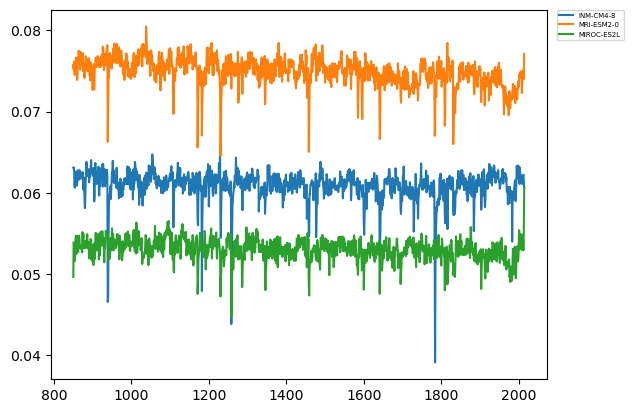

In [3]:
# CHOOSE - STEP 1/12
hovopt='nohov' 
#hovopt='hov' #required for Hovmuller with RSDT (1/4)
#####################

filech='/global/cfs/projectdirs/m4581/bonfils2/CMIP5/historical/atm/mo/tas/tas_Amon_CCSM4_historical_r1i1p1_185001-200512.nc'
ds = xc.open_dataset(filech,add_bounds=('X','Y'),decode_times=True,center_times=True)
ds.lat.attrs["axis"] = "Y"
ds.lon.attrs["axis"] = "X"
era = 'CMIP6'
exps=['past1000']
variables = ['tas']
if hovopt=='hov': variables = ['rsdt']
fnames={}
modripfs=[]
for exp in exps:
    fnames[exp]={}
    for var in variables:
        fnames[exp][var]={}
EOFopt='eofs'
##################
var="tas"
if hovopt=='hov': var="rsdt"
##################


models=['INM-CM4-8', 'MRI-ESM2-0', 'MIROC-ES2L']
dpaths=['/global/cfs/projectdirs/m4581/bonfils2/DATA_FOR_WENGANG/INM-CM4-8/',\
        '/global/cfs/projectdirs/m4581/bonfils2/DATA_FOR_WENGANG/MRI-ESM2-0/',\
        '/global/cfs/projectdirs/m4581/bonfils2/DATA_FOR_WENGANG/MIROC-ES2L/']
modeli_dpathss=['/global/cfs/projectdirs/m4581/bonfils2/CMIP6/CMIP/past1000/INM-CM4-8/r1i1p1f1/Amon/rsdt/gr1/v20220526/', \
 '/global/cfs/projectdirs/m4581/bonfils2/CMIP6/CMIP/past1000/MRI-ESM2-0/r1i1p1f1/Amon/rsdt/gn/v20200120/',\
 '/global/cfs/projectdirs/m4581/bonfils2/CMIP6/CMIP/past1000/MIROC-ES2L/r1i1p1f2/Amon/rsdt/gn/v20200318/']

custom_seasons = [
    ["Jan", "Feb", "Mar"],  
    ["Apr", "May", "Jun"],  
    ["Jul", "Aug", "Sep"],  
    ["Oct", "Nov", "Dec"],]

nsteps=1165
fault=[]
listats=[]
listatss=[]
listeavats=[]
for i in range(len(models)):
    print(models[i])
    modeli_dpaths=modeli_dpathss[i]
    print(modeli_dpaths)
    if i==0:dato1=first_check(dpaths[1],'JAS')[0]
    timseri=[]
    avts=[]
    ats= xr.DataArray(data=np.zeros((len(modeli_dpaths),5,nsteps)),coords={"rips":list(range(len(modeli_dpaths))), "vars":list(range(5)),"time": dato1.time}, dims=["rips","vars","time"],)
    eavats= xr.DataArray(data=np.zeros((len(models),5,nsteps)), coords={"modeli":list(range(len(models))), "vars":list(range(5)),"time": dato1.time}, dims=["modeli","vars","time"],)
    for j in range(1):
        dsi=modeli_dpaths[j]
        print('dsi',dsi)
        datas=first_check(dpaths[i],'JAS')
        if datas[0].shape[0]==nsteps:
            ats[j,0,:]=datas[0].values
            ats[j,1,:]=datas[1].values
            ats[j,2,:]=datas[2].values
            ats[j,3,:]=datas[3].values
            ats[j,4,:]=datas[4].values
        listats.append(ats)
    eavg=ats.mean(dim="rips")
    eavats[j]=eavg
    listeavats.append(eavg)
    listatss.append(listats)
    dataplot=eavats[0][4]
    unitsq=dataplot.time.encoding['units']
    calendarq = dataplot[0].time.encoding['calendar']
    axrmyq=dataplot["time"].to_index().year 
    data_xrq = xr.DataArray(axrmyq, coords={'time': axrmyq}, dims=['time'])
    line,=plt.plot(data_xrq[0:],dataplot[0:])
    line.set_label(models[i])
    plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0,fontsize=5)
    #plt.savefig('temperature_tas_NHmSH_jas_3models.png') 
    #plt.savefig('temperature_tas_NHmSH_jas_3models.pdf')


In [4]:
# STEP 2/12
dato1.shape
from xcdat import bounds
ds.bounds.keys
dpaths

['/global/cfs/projectdirs/m4581/bonfils2/DATA_FOR_WENGANG/INM-CM4-8/',
 '/global/cfs/projectdirs/m4581/bonfils2/DATA_FOR_WENGANG/MRI-ESM2-0/',
 '/global/cfs/projectdirs/m4581/bonfils2/DATA_FOR_WENGANG/MIROC-ES2L/']

In [5]:
######################
# LOADING TEMPERATURE - STEP 3/12
var='tas'
# IN ORDER TO SAVE:
# --> XTAS=X
# --> XTASstd=Xsstd
# --> pcsF0_TAS=pcs
##########################
# ADJUST MRI-ESM2-0 and CESM2
adjustPast100Hist='adjustPast100Hist'; Delta='ADJ'
##########################

nsteps=1165 
plotdas=[]
plotdaPIs=[]

# For the analyses
modelits=['INM-CM4-8', 'MRI-ESM2-0', 'MIROC-ES2L','CESM2','CESM1',\
          'CESM1','CESM1','CESM1','CESM1','CESM1','CESM1','CESM1']
dpaths=['/global/cfs/projectdirs/m4581/bonfils2/DATA_FOR_WENGANG/INM-CM4-8/',\
        '/global/cfs/projectdirs/m4581/bonfils2/DATA_FOR_WENGANG/MRI-ESM2-0/',\
        '/global/cfs/projectdirs/m4581/bonfils2/DATA_FOR_WENGANG/MIROC-ES2L/',\
        '/global/cfs/projectdirs/m4581/bonfils2/DATA_FOR_WENGANG/CESM2_bis/',\
        '/global/cfs/projectdirs/m4581/bonfils2/DATA_FOR_WENGANG/CESM1/',\
        '/global/cfs/projectdirs/m4581/bonfils2/DATA_FOR_WENGANG/CESM1/',\
        '/global/cfs/projectdirs/m4581/bonfils2/DATA_FOR_WENGANG/CESM1/',\
        '/global/cfs/projectdirs/m4581/bonfils2/DATA_FOR_WENGANG/CESM1/',\
        '/global/cfs/projectdirs/m4581/bonfils2/DATA_FOR_WENGANG/CESM1/',\
        '/global/cfs/projectdirs/m4581/bonfils2/DATA_FOR_WENGANG/CESM1/',\
        '/global/cfs/projectdirs/m4581/bonfils2/DATA_FOR_WENGANG/CESM1/',\
        '/global/cfs/projectdirs/m4581/bonfils2/DATA_FOR_WENGANG/CESM1/']

for ik in range(12):
    print(ik,dpaths[ik])

latitcz= xr.DataArray(data=np.zeros((len(models),nsteps)),coords={"modeli":list(range(len(models))),"time": dato1.time}, dims=["modeli","time"],)
custom_seasons = [
    ["Jan", "Feb", "Mar"],  
    ["Apr", "May", "Jun"],  
    ["Jul", "Aug", "Sep"],  
    ["Oct", "Nov", "Dec"],]

for ikc in range(5):
    print('ikc',ikc,"/4")
    if ikc==0:
        if var=='pr': filename="/global/cfs/projectdirs/m4581/bonfils2/CMIP6/CMIP/piControl/INM-CM5-0/r1i1p1f1/Amon/pr/gr1/v20190619/"
        if var=='tas':filename="/global/cfs/projectdirs/m4581/bonfils2/CMIP6/CMIP/piControl/INM-CM5-0/r1i1p1f1/Amon/tas/gr1/9/"
    if ikc==1: 
        if var=='pr': filename="/global/cfs/projectdirs/m4581/bonfils2/CMIP6/CMIP/piControl/MRI-ESM2-0/r1i1p1f1/Amon/pr/gn/v20190222/"
        if var=='tas':filename="/global/cfs/projectdirs/m4581/bonfils2/CMIP6/CMIP/piControl/MRI-ESM2-0/r1i1p1f1/Amon/tas/gn/v20190222/"
    if ikc==2: 
        if var=='pr': filename="/global/cfs/projectdirs/m4581/bonfils2/CMIP6/CMIP/piControl/MIROC-ES2L/r1i1p1f2/Amon/pr/gn/v20190823/"
        if var=='tas':filename="/global/cfs/projectdirs/m4581/bonfils2/CMIP6/CMIP/piControl/MIROC-ES2L/r1i1p1f2/Amon/tas/gn/9/"
    if ikc==3: 
        if var=='pr': filename="/global/cfs/projectdirs/m4581/bonfils2/DATA_FOR_WENGANG/CESM2_bis/CONTROL/pr_Amon_CESM2-WACCM_piControl_r1i1p1f1_gn_020501-110812.nc"
        if var=='tas':filename="/global/cfs/projectdirs/m4581/bonfils2/DATA_FOR_WENGANG/CESM2_bis/CONTROL/tas_Amon_CESM2-WACCM_piControl_r1i1p1f1_gn_020501-110812.nc"
    if ikc==4: 
        if var=='pr': filename="/global/cfs/projectdirs/m4581/bonfils2/CMIP6/CMIP/piControl/CESM1-CAM5/r1i1p1/Amon/pr/gu/v20130313/"
        if var=='tas':filename="/global/cfs/projectdirs/m4581/bonfils2/CMIP6/CMIP/piControl/CESM1-CAM5/r1i1p1/Amon/tas/gu/v20130313/"
    print(filename)
    dsPI=xc.open_mfdataset(filename,add_bounds=('X','Y'),decode_times=True,center_times=True)
    #print(dsPI.encoding.get('source', None))
    #print(dsPI)
    dsPI= dsPI.sel(time=dsPI.time.dt.month.isin([7, 8, 9]))
    #print(ikc, dsPI.time)
    dsPI = dsPI.bounds.add_bounds("T")
    dsPI = dsPI.temporal.group_average(var, freq="season",weighted=True,season_config={"custom_seasons": custom_seasons})
    #print(dsPI.time)
    dsPI=dsPI.sel(lat=slice(-90, 90))
    weights4lon = dsPI.spatial.get_weights(axis=['X'], lon_bounds=[0,360]) 
    ts_latPI = dsPI.spatial.average(var,axis=["X"],weights=weights4lon)[var]
    plotdaPI=ts_latPI
    plotdaPI=plotdaPI.transpose("lat","time")
    plotdaPI["lat"]=ts_latPI["lat"]
    plotdaPIs.append(plotdaPI)

for ik in range(12):
    print('ik',ik,"/11")
    whichmodel=ik
    print(dpaths[ik]+var+'*.nc')
    if ik==0:ds=xc.open_mfdataset(dpaths[ik]+var+'*.nc',add_bounds=('X','Y'),decode_times=True,center_times=True)
    if ik==1:ds=xc.open_mfdataset(dpaths[ik]+var+'*.nc',add_bounds=('X','Y'),decode_times=True,center_times=True)
    if ik==2:ds=xc.open_mfdataset(dpaths[ik]+var+'*.nc',add_bounds=('X','Y'),decode_times=True,center_times=True)
    if ik==3:ds=xc.open_mfdataset(dpaths[ik]+var+'*W*r3*085001-201412.nc',add_bounds=('X','Y'),decode_times=True,center_times=True)
    if ik==4:ds=xc.open_mfdataset(dpaths[ik]+var+'*ALL*2100*.nc',add_bounds=('X','Y'),decode_times=True,center_times=True)
    if ik==5:ds=xc.open_mfdataset(dpaths[ik]+var+'*ALL*2005*.nc',add_bounds=('X','Y'),decode_times=True,center_times=True)
    if ik==6:ds=xc.open_mfdataset(dpaths[ik]+var+'*GHG*.nc',add_bounds=('X','Y'),decode_times=True,center_times=True)
    if ik==7:ds=xc.open_mfdataset(dpaths[ik]+var+'*ORB*.nc',add_bounds=('X','Y'),decode_times=True,center_times=True)
    if ik==8:ds=xc.open_mfdataset(dpaths[ik]+var+'*VOL*.nc',add_bounds=('X','Y'),decode_times=True,center_times=True)
    if ik==9:ds=xc.open_mfdataset(dpaths[ik]+var+'*AER*.nc',add_bounds=('X','Y'),decode_times=True,center_times=True)
    if ik==10:ds=xc.open_mfdataset(dpaths[ik]+var+'*LU*.nc',add_bounds=('X','Y'),decode_times=True,center_times=True)
    if ik==11:ds=xc.open_mfdataset(dpaths[ik]+var+'*SSI*.nc',add_bounds=('X','Y'),decode_times=True,center_times=True)
    #print(ds.encoding.get('source', None))
    ds= ds.sel(time=ds.time.dt.month.isin([7, 8, 9]))
    #print(ik, ds.time)
    ds = ds.bounds.add_bounds("T")
    ds = ds.temporal.group_average(var, freq="season",weighted=True,season_config={"custom_seasons": custom_seasons})
    #print(ds.time)
    ds=ds.sel(lat=slice(-90, 90))
    weights4lon = ds.spatial.get_weights(axis=['X'], lon_bounds=[0,360]) 
    ts_lat = ds.spatial.average(var,axis=["X"],weights=weights4lon)[var]
    # PI section
    if "PI_needed"=="NO_PI_needed":
     if modelits[whichmodel]!='CESM1':
        pathDictPI = xs.findPaths('piControl', var, 'mon', mip_era='CMIP6', realm='atmos',model=modelits[whichmodel])
        dpathPIs=xs.getValuesForFacet(pathDictPI,'model',modelits[whichmodel])
     if modelits[whichmodel]=='CESM1':
        pathDictPI = xs.findPaths('piControl', var, 'mon', mip_era='CMIP5', realm='atmos',model='CESM1-CAM5')
        dpathPIs=xs.getValuesForFacet(pathDictPI,'model','CESM1-CAM5')
     dsPI=xc.open_mfdataset(dpathPIs[0]+'*.nc',add_bounds=('X','Y'),decode_times=True,center_times=True)
     #dsPI = dsPI.temporal.group_average(var, freq="year", weighted=True)
     dsPI=dsPI.sel(time=(dsPI.time.dt.season == "JJA"))
     dsPI = dsPI.temporal.climatology(var, freq="season",weighted=True)
     dsPI=dsPI.sel(lat=slice(inp1, inp2))
     weights4lon = dsPI.spatial.get_weights(axis=['X'], lon_bounds=[0,360]) 
     ts_latPI = dsPI.spatial.average(var,axis=["X"],weights=weights4lon)[var]
     # end PI Section
    plotda=ts_lat[:,]
    plotda=plotda.transpose("lat","time")
    plotda["lat"]=ts_lat["lat"]
    # ADJUSTMENTS
    # ADJUST between past1000 and historical
    if modelits[whichmodel]=='MRI-ESM2-0' or modelits[whichmodel]=='CESM2':
     if 'adjustPast100Hist'==adjustPast100Hist: # by latitude
        print(modelits[whichmodel], 'TAS IS ADJUSTED')
        delta0=plotda[:,1000:1050].mean(dim=['time']).values-plotda[:,950:1000].mean(dim=['time'])
        delta0=xr.DataArray(delta0, coords={'lat': plotda["lat"].to_index()}, dims=["lat"])
        plotda[:,1000:]=plotda[:,1000:]-delta0
    # ADJUST UNITS
    if modelits[whichmodel]=='CESM1'and ik==4 and var=='pr': plotda=plotda[:,:-86]/86400
    if modelits[whichmodel]=='CESM1'and ik>4  and var=='pr': plotda=plotda/86400
    if modelits[whichmodel]=='CESM1'and ik==4 and var=='tas': plotda=plotda[:,:-86]
    if modelits[whichmodel]=='CESM1'and ik>4  and var=='tas': plotda=plotda
    # CESM2 is already in kg m-2 s-1 - no convertion required
    plotdas.append(plotda)
    # PI ADJUSTMENTS IF NEEDED
    if "P_needed"=="NO_PI_needed":
     plotdaPI=ts_latPI; plotdaPI=plotdaPI.squeeze()
     plotdaPI["lat"]=ts_latPI["lat"]
     dda=plotda-plotdaPI.mean("lat")
     print(dsPI[var][-360:,:,:])


0 /global/cfs/projectdirs/m4581/bonfils2/DATA_FOR_WENGANG/INM-CM4-8/
1 /global/cfs/projectdirs/m4581/bonfils2/DATA_FOR_WENGANG/MRI-ESM2-0/
2 /global/cfs/projectdirs/m4581/bonfils2/DATA_FOR_WENGANG/MIROC-ES2L/
3 /global/cfs/projectdirs/m4581/bonfils2/DATA_FOR_WENGANG/CESM2_bis/
4 /global/cfs/projectdirs/m4581/bonfils2/DATA_FOR_WENGANG/CESM1/
5 /global/cfs/projectdirs/m4581/bonfils2/DATA_FOR_WENGANG/CESM1/
6 /global/cfs/projectdirs/m4581/bonfils2/DATA_FOR_WENGANG/CESM1/
7 /global/cfs/projectdirs/m4581/bonfils2/DATA_FOR_WENGANG/CESM1/
8 /global/cfs/projectdirs/m4581/bonfils2/DATA_FOR_WENGANG/CESM1/
9 /global/cfs/projectdirs/m4581/bonfils2/DATA_FOR_WENGANG/CESM1/
10 /global/cfs/projectdirs/m4581/bonfils2/DATA_FOR_WENGANG/CESM1/
11 /global/cfs/projectdirs/m4581/bonfils2/DATA_FOR_WENGANG/CESM1/
ikc 0 /4
/global/cfs/projectdirs/m4581/bonfils2/CMIP6/CMIP/piControl/INM-CM5-0/r1i1p1f1/Amon/tas/gr1/9/
ikc 1 /4
/global/cfs/projectdirs/m4581/bonfils2/CMIP6/CMIP/piControl/MRI-ESM2-0/r1i1p1f1/Amon/ta

In [6]:
# CHECK
print(modelits)
print(len(plotdas))
for i in range(12):
    print(i,plotdas[i].shape)
print("PIC")
for i in range(5):
    print(i,plotdaPIs[i].shape)

['INM-CM4-8', 'MRI-ESM2-0', 'MIROC-ES2L', 'CESM2', 'CESM1', 'CESM1', 'CESM1', 'CESM1', 'CESM1', 'CESM1', 'CESM1', 'CESM1']
12
0 (120, 1165)
1 (160, 1165)
2 (64, 1165)
3 (96, 1165)
4 (96, 1165)
5 (96, 1156)
6 (96, 1156)
7 (96, 1156)
8 (96, 1156)
9 (96, 1156)
10 (96, 1156)
11 (96, 1156)
PIC
0 (120, 1201)
1 (160, 701)
2 (64, 500)
3 (96, 904)
4 (192, 319)


In [7]:
# GET datait_xrq for 'tas' - STEP 4/12
#from scipy.signal import savgol_filter
axrmyqit=latitcz["time"].to_index().year
datait_xrq = xr.DataArray(axrmyqit, coords={'time': axrmyqit}, dims=['time'])

<xarray.DataArray (time: 1015)> Size: 8kB
array([1000, 1001, 1002, ..., 2012, 2013, 2014], shape=(1015,))
Coordinates:
  * time     (time) int64 8kB 1000 1001 1002 1003 1004 ... 2011 2012 2013 2014
<xarray.DataArray 'tas' (time: 1015)> Size: 8kB
dask.array<getitem, shape=(1015,), dtype=float64, chunksize=(1,), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) object 8kB 1000-08-01 00:00:00 ... 2014-08-01 00:00:00
<xarray.DataArray 'tas' (time: 1006)> Size: 8kB
dask.array<getitem, shape=(1006,), dtype=float64, chunksize=(1,), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) object 8kB 1000-08-01 00:00:00 ... 2005-08-01 00:00:00


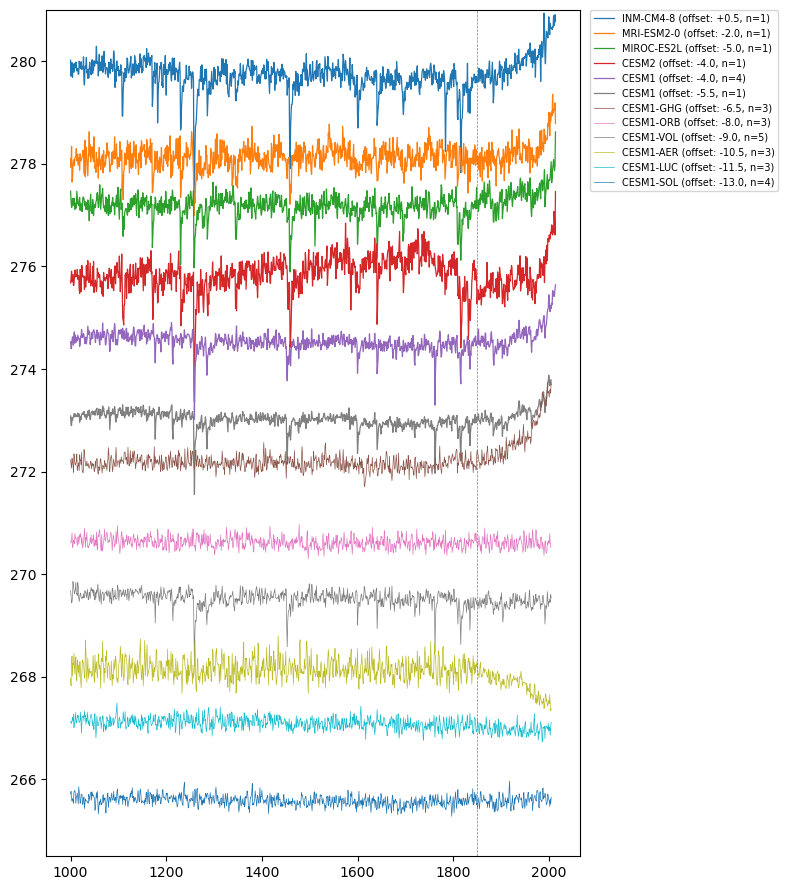

In [8]:
# TEMPERATURE TIME-SERIES
if 'fig'=='fig':
    aa=150; ab=-9
    print(datait_xrq[aa:])
    print(plotdas[0].mean(axis=0)[aa:])
    print(plotdas[6].mean(axis=0)[aa:aa+1015])
    %matplotlib inline
    datait_xrq[950:1000]
    if var=="tas": fc=1
    if var=="pr":  fc=864000
    fig, (ax0) = plt.subplots(nrows=1,figsize=(8,9))
    if var=='tas':ax0.plot(datait_xrq[aa:],plotdas[0].mean(axis=0)[aa:]+0.5/fc,linewidth=0.9,label=modelits[0]+' (offset: +0.5, n=1)')
    if var=='pr': ax0.plot(datait_xrq[aa:],plotdas[0].mean(axis=0)[aa:]+0.0/fc,linewidth=0.9,label=modelits[0]+' (offset: +0.0, n=1)')
    ax0.plot(datait_xrq[aa:],plotdas[1].mean(axis=0)[aa:]-2.0/fc,linewidth=0.9,label=modelits[1]+' (offset: -2.0, n=1)')
    ax0.plot(datait_xrq[aa:],plotdas[2].mean(axis=0)[aa:]-5.0/fc,linewidth=0.9,label=modelits[2]+' (offset: -5.0, n=1)')
    ax0.plot(datait_xrq[aa:],plotdas[3].mean(axis=0)[aa:]-4.0/fc,linewidth=0.9,label=modelits[3]+' (offset: -4.0, n=1)')
    if var=='tas':ax0.plot(datait_xrq[aa:],plotdas[4].mean(axis=0)[aa:]-4.0/fc,linewidth=0.9,label=modelits[4]+' (offset: -4.0, n=4)')
    if var=='pr': ax0.plot(datait_xrq[aa:],plotdas[4].mean(axis=0)[aa:]-5.0/fc,linewidth=0.9,label=modelits[4]+' (offset: -5.0, n=4)')
    if var=='tas':ax0.plot(datait_xrq[aa:ab],plotdas[5].mean(axis=0)[aa:]-5.5/fc,color='grey',linewidth=0.9,label=modelits[5]+' (offset: -5.5, n=1)')
    if var=='pr': ax0.plot(datait_xrq[aa:ab],plotdas[5].mean(axis=0)[aa:]-8.5/fc,color='grey',linewidth=0.9,label=modelits[5]+' (offset: -8.5, n=1)')
    ax0.plot(datait_xrq[aa:ab],plotdas[6].mean(axis=0)[aa:]-6.5/fc,linewidth=0.5,label=modelits[8]+'-GHG (offset: -6.5, n=3)')
    ax0.plot(datait_xrq[aa:ab],plotdas[7].mean(axis=0)[aa:]-8.0/fc,linewidth=0.5,label=modelits[8]+'-ORB (offset: -8.0, n=3)')
    ax0.plot(datait_xrq[aa:ab],plotdas[8].mean(axis=0)[aa:]-9.0/fc,linewidth=0.5,label=modelits[8]+'-VOL (offset: -9.0, n=5)')
    ax0.plot(datait_xrq[aa:ab],plotdas[9].mean(axis=0)[aa:]-10.5/fc,linewidth=0.5,label=modelits[8]+'-AER (offset: -10.5, n=3)')
    ax0.plot(datait_xrq[aa:ab],plotdas[10].mean(axis=0)[aa:]-11.5/fc,linewidth=0.5,label=modelits[8]+'-LUC (offset: -11.5, n=3)')
    if var=='tas':ax0.plot(datait_xrq[aa:ab],plotdas[11].mean(axis=0)[aa:]-13.0/fc,linewidth=0.5,label=modelits[8]+'-SOL (offset: -13.0, n=4)')
    if var=='pr':ax0.plot(datait_xrq[aa:ab],plotdas[11].mean(axis=0)[aa:]-13.0/fc,linewidth=0.5,label=modelits[8]+'-SOL (offset: -13.0, n=4)')
    if var=='tas':ax0.set_ylim(264.5,281)
    if var=='pr':ax0.set_ylim(1.3e-5,3e-5)
    if var=='tas':ax0.plot([datait_xrq[1000],datait_xrq[1000]],[264.5,281],linestyle='dashed',markersize=0,color='0.5',linewidth=0.5,zorder=2)
    if var=='pr':ax0.plot([datait_xrq[1000],datait_xrq[1000]],[1.3e-5,3e-5],linestyle='dashed',markersize=0,color='0.5',linewidth=0.5,zorder=2)
    ax0.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0,fontsize=7)
    fig.tight_layout()
    #plt.savefig('Timeseries_data_'+var+'_jas_mean_5models_REVISIONS3_'+Delta+'.png')
    #plt.savefig('Timeseries_data_'+var+'_jas_mean_5models_REVISIONS3_'+Delta+'.pdf')

ik 0
(1165, 54) (54,)
X -0.0070637528738473065
Xs -0.0070637528738473065 nk= 1
Xcumul -0.0070637528738473065 nk= 1
ik 1
(1165, 54) (54,)
X 1.0351063393239315
Xs 1.0280425864500842 nk= 2
Xcumul 1.0280425864500842 nk= 2
ik 2
(1165, 54) (54,)
X 0.7479835233096139
Xs 1.776026109759698 nk= 3
Xcumul 1.776026109759698 nk= 3
ik 3
(1165, 54) (54,)
X -0.8903537377112514
Xs 0.8856723720484467 nk= 4
Xcumul 0.8856723720484467 nk= 4
ik 4
(1165, 54) (54,)
X -0.426653301411676
Xs 0.4590190706367707 nk= 5
Xcumul 0.4590190706367707 nk= 5
univariate_tas_diff_jas_eofs_pcscaling1_coslatyes_diff_5models_REVISIONS.png  eof name figure


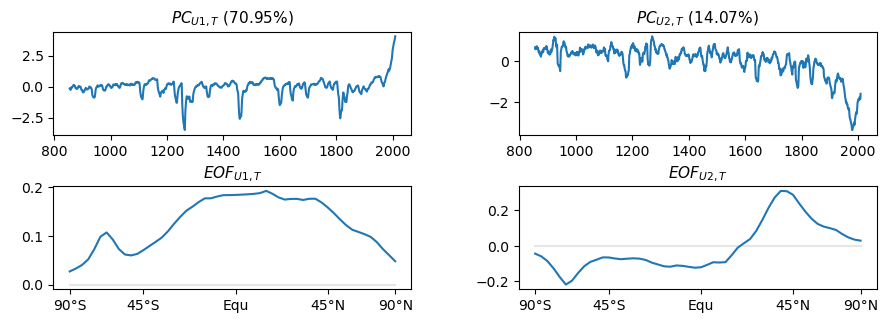

In [9]:
# UNIVARIATE ANALYSIS FOR T - STEP 5/12 (USING indu='diff')
multiv='no'

def findindex(latax,latvalue):
    #find nearest index of a given lat
    a = abs(latax-(latvalue)) 
    i=np.unravel_index(a.argmin(), a.shape)
    return i[0]

if EOFopt=='eofs':   
 #indu='std'
 indu='diff'
 stdm='PIC'
 #stdm='SEL'
 #if multiv=='no': indu='diff' # best option for pr and tas univariate
 #if multiv=='yes': indu='std' # best option for pr and tas multivariate
 indweight='yes' # best option for tas
 #indweight='no' # best option for pr
 avemodels='yes' # best option for pr and tas univariate!
 figname='reve'
 if var=='tas' and multiv=='no' and indu=='diff':figname='univariate_tas_diff' 
 if var=='pr' and multiv=='no'and indu=='diff':figname='univariate_pr_diff'
 if var=='tas' and multiv=='no' and indu=='std':figname='univariate_tas_std' 
 if var=='pr' and multiv=='no'and indu=='std':figname='univariate_pr_std'
 if var=='pr' and avemodels=='yes' and multiv=='yes':figname='multivariate_tas_pr_std' 
 pcsa=0
 Xs=0
 Xsstd=0
 if var=='tas': varname='Temperature' 
 if var=='pr': varname='Precipitation' 
 if multiv=='no':
  fig, axes = plt.subplots(nrows=2,ncols=2, figsize=(9, 5*4/6))
  ax0 = axes[0, 0]
  ax1 = axes[1, 0]
  ax3 = axes[0, 1]
  ax4 = axes[1, 1]
 if multiv=='yes':
  fig, axes = plt.subplots(nrows=3,ncols=2, figsize=(9, 5))
  ax0 = axes[0, 0]
  ax1 = axes[1, 0]
  ax2 = axes[2, 0]
  ax3 = axes[0, 1]
  ax4 = axes[1, 1]
  ax5 = axes[2, 1]
 nk=0
 for ik in range(5):
    print('ik',ik)
    plotda=plotdas[ik].transpose("time","lat")
    lati  = np.arange(-80, 80, 3)
    plotda=plotda.interp({'lat': lati})
    X=np.array(plotda)
    weights_array=np.cos(np.deg2rad(plotda.lat))[:]; print(X.shape, weights_array.shape)
    #PI
    plotdaPI=plotdaPIs[ik].transpose("time","lat")
    latiPI  = np.arange(-80, 80, 3)
    plotdaPI=plotdaPI.interp({'lat': latiPI})
    XPI=np.array(plotdaPI)
    #
    if stdm=='PIC' and indu=='std':  Xstd=np.std(XPI,axis=0); X = (X - np.mean (X, axis=0)) / np.std(XPI, axis=0)
    if stdm=='SEL' and indu=='std':  Xstd=np.std(X,axis=0); X = (X - np.mean (X, axis=0)) / np.std(X, axis=0)
    if var=='tas' and indu=='diff': X = (X - np.mean (X, axis=0))
    if var=='pr'  and indu=='diff': X = (X - np.mean (X, axis=0))
    if ik==0: XINM=X 
    if ik==1: XMRI=X
    if ik==2: XMIR=X
    if ik==3: XACC=X 
    if ik==4: XCES=X
    if avemodels=='yes':
        print('X',X[0,0])
        Xs=Xs+np.array(X); nk=nk+1
        print('Xs',Xs[0,0],'nk=',nk)
        X=Xs
        XMRI = xr.DataArray(X, coords={'time':plotda[:].time,'lat': plotda.lat}, dims=["time","lat"])
        if indu=='std':Xsstd=Xsstd+np.array(Xstd); #print('std',Xstd[0])
        modname='5models'
        if var=='tas': mult0=-1; mult1=1
        if var=='pr' and indu=='std': mult0=-1; mult1=-1
        if var=='pr' and indu=='diff': mult0=-1; mult1=-1
    print('Xcumul',X[0,0],'nk=',nk)
    if avemodels=='yes' and ik==0: continue
    if avemodels=='yes' and ik==1: continue
    if avemodels=='yes' and ik==2: continue
    if avemodels=='yes' and ik==3: continue
    Xa=X/nk
    Xstda=Xsstd/nk
    if multiv=='yes':XTASa=XTAS/nk 
    if multiv=='yes':XTASstda=XTASstd/nk
    #
    if var=='tas'and indweight=='yes':tsolverF0  = Eof(Xa,weights=weights_array) 
    if var=='tas'and indweight=='no':tsolverF0  = Eof(Xa) 
    if var=='pr'and indweight=='no':tsolverF0  = Eof(Xa)
    if var=='pr' and indweight=='yes' : print('here'); tsolverF0  = Eof(Xa,weights=weights_array) ; print('weighted') 
    if multiv=='yes':  print('hore',indu); tsolverF0  = MultivariateEof([XTASa[:],Xa[:]],weights=[weights_array,weights_array],center=False)
    #
    if "PROJECTIONS"=="noPROJECTIONS":
        print("no projections")
    if multiv=='no':
        meofF0 = tsolverF0.eofs(neofs=3)
        if indu=='std': meofF0 = meofF0*Xstda; print('multiplied by std')
        tpcsF0=tsolverF0.projectField(Xa, neofs=3, eofscaling=1)
        pcsF0 = tsolverF0.pcs(npcs=3,pcscaling=1)
    if multiv=='yes':
        if indu=='std': meofF0 = meofF0*Xstda; print('multiplied by std')
        meofF02, meofF0=tsolverF0.eofs(neofs=3)
        meofF02=meofF02*XTASstda; print('multiplied by std')
        meofF0=meofF0*Xstda; print('multiplied by std')
        pcsF0 = tsolverF0.pcs(npcs=3,pcscaling=1) 
        tpcsF0=tsolverF0.projectField([XTASa,Xa], neofs=3, eofscaling=1)
    pcsF0 = xr.DataArray(pcsF0, coords={'time':plotda[:].time,'numb':list(range(3)) }, dims=["time","numb"])
    tpcsF0 = xr.DataArray(tpcsF0, coords={'time':plotda[:].time,'numb':list(range(3)) }, dims=["time","numb"])
    if 'save_netcdf'=='nosave_netcdf':
     raise
    varexpF0= tsolverF0.varianceFraction()*100.
    #
    runav=11
    #runav=5
    #runav=1
    if multiv=='yes': 
        ax1.plot(meofF02[0]*mult0,label='',zorder=2)
        ax2.plot(meofF0[0]*mult0,label='',zorder=2)
        ax0.plot(datait_xrq[:],pcsF0[:,0].rolling(time=runav, center=True).mean('time')*mult0,label='',zorder=2)
    if multiv=='no': 
        ax1.plot(meofF0[0]*mult0,label='',zorder=2)
        ax0.plot(datait_xrq[:],pcsF0[:,0].rolling(time=runav, center=True).mean('time')*mult0,label='',zorder=2)
    if multiv=='yes': 
        ax4.plot(meofF02[1]*mult1,label='',zorder=2)
        ax5.plot(meofF0[1]*mult1,label='',zorder=2)
        ax3.plot(datait_xrq[:],pcsF0[:,1].rolling(time=runav, center=True).mean('time')*mult1,label='',zorder=2)    
    if multiv=='no': 
        ax4.plot(meofF0[1]*mult1*1,label='',zorder=2)
        ax3.plot(datait_xrq[:],pcsF0[:,1].rolling(time=runav, center=True).mean('time')*mult1*1,label='',zorder=2) 
    x_tick_labels = [u'90\N{DEGREE SIGN}S', u'45\N{DEGREE SIGN}S', u'Equ', u'45\N{DEGREE SIGN}N',u'90\N{DEGREE SIGN}N']
    ax1.set_xticks([findindex(plotda.lat,-90),findindex(plotda.lat,-45),findindex(plotda.lat,0),findindex(plotda.lat,45),findindex(plotda.lat,90)])
    ax1.set_xticklabels(x_tick_labels)
    ax4.set_xticks([findindex(plotda.lat,-90),findindex(plotda.lat,-45),findindex(plotda.lat,0),findindex(plotda.lat,45),findindex(plotda.lat,90)])
    ax4.set_xticklabels(x_tick_labels)
    if multiv=='yes':
        ax2.set_xticks([findindex(plotda.lat,-90),findindex(plotda.lat,-45),findindex(plotda.lat,0),findindex(plotda.lat,45),findindex(plotda.lat,90)])
        ax2.set_xticklabels(x_tick_labels)
        ax5.set_xticks([findindex(plotda.lat,-90),findindex(plotda.lat,-45),findindex(plotda.lat,0),findindex(plotda.lat,45),findindex(plotda.lat,90)])
        ax5.set_xticklabels(x_tick_labels)
    if multiv=='yes':
        ax0.set_title(r'$PC_{M1}$' +' ('+str(round(varexpF0[0],2))+'%)',fontsize=11)
        ax1.set_title(r'$EOF_{M1,T}$',fontsize=11)
        ax2.set_title(r'$EOF_{M1,P}$',fontsize=11)
        ax3.set_title(r'$PC_{M2}$' +' ('+str(round(varexpF0[1],2))+'%)',fontsize=11)
        ax4.set_title(r'$EOF_{M2,T}$',fontsize=11)
        ax5.set_title(r'$EOF_{M2,P}$',fontsize=11)
    if multiv=='no':
        ax0.set_title(r'$PC_{U1,'+varname[0]+'}$' +' ('+str(round(varexpF0[0],2))+'%)',fontsize=11)
        ax1.set_title(r'$EOF_{U1,'+varname[0]+'}$',fontsize=11)
        ax3.set_title(r'$PC_{U2,'+varname[0]+'}$' +' ('+str(round(varexpF0[1],2))+'%)',fontsize=11)
        ax4.set_title(r'$EOF_{U2,'+varname[0]+'}$',fontsize=11)
    ax1.plot(meofF0[1]*0,color='0.9',zorder=1)
    if multiv=='yes':ax2.plot(meofF0[1]*0,color='0.9',zorder=1)
    ax4.plot(meofF0[1]*0,color='0.9',zorder=1)
    if multiv=='yes':ax5.plot(meofF0[1]*0,color='0.9',zorder=1)
    plt.subplots_adjust(bottom=0.05, right=0.9, top=0.94,hspace=0.29)
    print(figname+'_jas_eofs_pcscaling1_coslat'+indweight+'_'+indu+'_'+modname+'_REVISIONS.png',' eof name figure')
    fig.tight_layout()
    fig.subplots_adjust(hspace=0.5, wspace=0.3)
    #plt.savefig('FINALREV_'+str(runav)+'_'+figname+'_5models_jas_eofs_pcscaling1_coslat'+indweight+'_'+indu+'_'+modname+'_REVISIONSct'+stdm+'NoDelta.png')
    #plt.savefig('FINALREV_'+str(runav)+'_'+figname+'_5models_jas_eofs_pcscaling1_coslat'+indweight+'_'+indu+'_'+modname+'_REVISIONSct'+stdm+'NoDelta.pdf'}

if multiv=='no' and var=='tas' and indu=='diff':
    ni_PC0_tasd_1=pcsF0[:,0].rolling(time=1, center=True).mean('time')*mult0
    ni_PC1_tasd_1=pcsF0[:,1].rolling(time=1, center=True).mean('time')*mult1
    ni_PC0_tasd_3=pcsF0[:,0].rolling(time=3, center=True).mean('time')*mult0
    ni_PC1_tasd_3=pcsF0[:,1].rolling(time=3, center=True).mean('time')*mult1
    ni_PC0_tasd_5=pcsF0[:,0].rolling(time=5, center=True).mean('time')*mult0
    ni_PC1_tasd_5=pcsF0[:,1].rolling(time=5, center=True).mean('time')*mult1
    ni_PC0_tasd_11=pcsF0[:,0].rolling(time=11, center=True).mean('time')*mult0
    ni_PC1_tasd_11=pcsF0[:,1].rolling(time=11, center=True).mean('time')*mult1

In [10]:
# MULTIVARIATE ANALYSIS - PREPARE XTAS - STEP 6/12 (USING indu='std')
multiv='no'

if EOFopt=='eofs':   
 indu='std'
 #indu='diff'
 stdm='PIC'
 #stdm='SEL'
 #if multiv=='no': indu='diff' # best option for pr and tas univariate
 #if multiv=='yes': indu='std' # best option for pr and tas multivariate
 indweight='yes' # best option for tas
 #indweight='no' # best option for pr
 avemodels='yes' # best option for pr and tas univariate!
 figname='reve'
 if var=='tas' and multiv=='no' and indu=='diff':figname='univariate_tas_diff' 
 if var=='pr' and multiv=='no'and indu=='diff':figname='univariate_pr_diff'
 if var=='tas' and multiv=='no' and indu=='std':figname='univariate_tas_std' 
 if var=='pr' and multiv=='no'and indu=='std':figname='univariate_pr_std'
 if var=='pr' and avemodels=='yes' and multiv=='yes':figname='multivariate_tas_pr_std'    
 pcsa=0
 Xs=0
 Xsstd=0
 if var=='tas': varname='Temperature' 
 if var=='pr': varname='Precipitation'
 nk=0
 for ik in range(5):
    print('ik',ik)
    plotda=plotdas[ik].transpose("time","lat")
    lati  = np.arange(-80, 80, 3)
    plotda=plotda.interp({'lat': lati})
    X=np.array(plotda)
    weights_array=np.cos(np.deg2rad(plotda.lat))[:]; print(X.shape, weights_array.shape)
    #PI
    plotdaPI=plotdaPIs[ik].transpose("time","lat")
    latiPI  = np.arange(-80, 80, 3)
    plotdaPI=plotdaPI.interp({'lat': latiPI})
    XPI=np.array(plotdaPI)
    #
    if stdm=='PIC' and indu=='std':  Xstd=np.std(XPI,axis=0); X = (X - np.mean (X, axis=0)) / np.std(XPI, axis=0)
    if stdm=='SEL' and indu=='std':  Xstd=np.std(X,axis=0); X = (X - np.mean (X, axis=0)) / np.std(X, axis=0)
    if var=='tas' and indu=='diff': X = (X - np.mean (X, axis=0))
    if var=='pr'  and indu=='diff': X = (X - np.mean (X, axis=0))
    if ik==0: XINM=X 
    if ik==1: XMRI=X
    if ik==2: XMIR=X
    if ik==3: XACC=X 
    if ik==4: XCES=X
    if avemodels=='yes':
        print('X',X[0,0])
        Xs=Xs+np.array(X); nk=nk+1
        print('Xs',Xs[0,0],'nk=',nk)
        X=Xs
        XMRI = xr.DataArray(X, coords={'time':plotda[:].time,'lat': plotda.lat}, dims=["time","lat"])
        #print(XMRI[30,10])
        if indu=='std':Xsstd=Xsstd+np.array(Xstd); #print('std',Xstd[0])
        modname='5models'
        if var=='tas': mult0=-1; mult1=1
        if var=='pr' and indu=='std': mult0=-1; mult1=-1
        if var=='pr' and indu=='diff': mult0=-1; mult1=-1
    print('Xcumul',X[0,0],'nk=',nk)
    if avemodels=='yes' and ik==0: continue
    if avemodels=='yes' and ik==1: continue
    if avemodels=='yes' and ik==2: continue
    if avemodels=='yes' and ik==3: continue
    Xa=X/nk
    Xstda=Xsstd/nk
    if multiv=='yes':XTASa=XTAS/nk 
    if multiv=='yes':XTASstda=XTASstd/nk
    if var=='tas'and indweight=='yes':tsolverF0  = Eof(Xa,weights=weights_array) 
    if var=='tas'and indweight=='no':tsolverF0  = Eof(Xa) 
    if var=='pr'and indweight=='no':tsolverF0  = Eof(Xa)
    if var=='pr' and indweight=='yes' : print('here'); tsolverF0  = Eof(Xa,weights=weights_array) ; print('weighted') 
    if multiv=='yes':  print('hore',indu); tsolverF0  = MultivariateEof([XTASa[:],Xa[:]],weights=[weights_array,weights_array],center=False)
    if "PROJECTIONS"=="PROJECTIONS":
     if var=='tas' and multiv=='no': YTAS4MULT=[]
     if var=='pr' and multiv=='no':  YPR4MULT=[]
     if var=='pr' and multiv=='yes':  YPR4MULT=[]
     for ikY in range(0,12,1):
        print('ikY',ikY,"/11")
        plotdaY=plotdas[ikY].transpose("time","lat")
        if ikY==0:plotdaYPI=plotdaPIs[0].transpose("time","lat")
        if ikY==1:plotdaYPI=plotdaPIs[1].transpose("time","lat")
        if ikY==2:plotdaYPI=plotdaPIs[2].transpose("time","lat")
        if ikY==3:plotdaYPI=plotdaPIs[3].transpose("time","lat")
        if ikY==4:plotdaYPI=plotdaPIs[4].transpose("time","lat")
        if ikY>4:plotdaYPI=plotdaPIs[4].transpose("time","lat")
        lati  = np.arange(-80, 80, 3)
        plotdaY=plotdaY.interp({'lat': lati})
        plotdaYPI=plotdaYPI.interp({'lat': lati})
        Y=np.array(plotdaY)
        YPI=np.array(plotdaYPI)
        weights_array=np.cos(np.deg2rad(plotdaY.lat))[:]
        if stdm=='SEL' and indu=='std':  Ystd=np.std(Y,axis=0); Y = (Y - np.mean (Y, axis=0)) / np.std(Y, axis=0)
        if stdm=='PIC' and indu=='std':  Ystd=np.std(YPI,axis=0); Y = (Y - np.mean (Y, axis=0)) / np.std(YPI, axis=0)
        if var=='tas' and indu=='diff': Y = (Y - np.mean (Y, axis=0))
        if var=='pr'  and indu=='diff': Y = (Y - np.mean (Y, axis=0)) 
        if var=='tas':YTAS4MULT.append(Y)
        if var=='pr':YPR4MULT.append(Y)
    if multiv=='no':
        meofF0 = tsolverF0.eofs(neofs=3)
        if indu=='std': meofF0 = meofF0*Xstda; print('multiplied by std')
        tpcsF0=tsolverF0.projectField(Xa, neofs=3, eofscaling=1)
        pcsF0 = tsolverF0.pcs(npcs=3,pcscaling=1)
    if multiv=='yes':
        if indu=='std': meofF0 = meofF0*Xstda; print('multiplied by std')
        meofF02, meofF0=tsolverF0.eofs(neofs=3)
        meofF02=meofF02*XTASstda; print('multiplied by std')
        meofF0=meofF0*Xstda; print('multiplied by std')
        pcsF0 = tsolverF0.pcs(npcs=3,pcscaling=1) 
        tpcsF0=tsolverF0.projectField([XTASa,Xa], neofs=3, eofscaling=1)
    pcsF0 = xr.DataArray(pcsF0, coords={'time':plotda[:].time,'numb':list(range(3)) }, dims=["time","numb"]) #-112
    tpcsF0 = xr.DataArray(tpcsF0, coords={'time':plotda[:].time,'numb':list(range(3)) }, dims=["time","numb"])
    if 'save_netcdf'=='nosave_netcdf':
     raise
    varexpF0= tsolverF0.varianceFraction()*100.


ik 0
(1165, 54) (54,)
X -0.006204203691618752
Xs -0.006204203691618752 nk= 1
Xcumul -0.006204203691618752 nk= 1
ik 1
(1165, 54) (54,)
X 0.8348102615679548
Xs 0.828606057876336 nk= 2
Xcumul 0.828606057876336 nk= 2
ik 2
(1165, 54) (54,)
X 0.8650934654937532
Xs 1.693699523370089 nk= 3
Xcumul 1.693699523370089 nk= 3
ik 3
(1165, 54) (54,)
X -0.6662209646354034
Xs 1.0274785587346857 nk= 4
Xcumul 1.0274785587346857 nk= 4
ik 4
(1165, 54) (54,)
X -0.4208056181790075
Xs 0.6066729405556782 nk= 5
Xcumul 0.6066729405556782 nk= 5
ikY 0 /11
ikY 1 /11
ikY 2 /11
ikY 3 /11
ikY 4 /11
ikY 5 /11
ikY 6 /11
ikY 7 /11
ikY 8 /11
ikY 9 /11
ikY 10 /11
ikY 11 /11
multiplied by std


In [11]:
#SAVE XTAS IN ORDER TO PERFORM THE MULTIVARIATE ANALYSIS - STEP 7/12
print(indu,stdm)
if indu!='std': print('WRONG! indu must be set to std')
XTAS=X
XTASstd=Xsstd
pcsF0_TAS=pcsF0
print(len(XTAS))

std PIC
1165


In [12]:
######################
# LOADING PRECIPITATION - STEP 8/12
#ONCE YOU SAVED:
# --> XTAS=X
# --> XTASstd=Xsstd
# --> pcsF0_TAS=pcs
var='pr' 
######################

nsteps=1165 
plotdas=[]
plotdaPIs=[]

# For the analyses
modelits=['INM-CM4-8', 'MRI-ESM2-0', 'MIROC-ES2L','CESM2','CESM1',\
          'CESM1','CESM1','CESM1','CESM1','CESM1','CESM1','CESM1']
spaths=['/global/cfs/projectdirs/m4581/bonfils2/DATA_FOR_WENGANG/INM-CM4-8/',\
        '/global/cfs/projectdirs/m4581/bonfils2/DATA_FOR_WENGANG/MRI-ESM2-0/',\
        '/global/cfs/projectdirs/m4581/bonfils2/DATA_FOR_WENGANG/MIROC-ES2L/',\
        '/global/cfs/projectdirs/m4581/bonfils2/DATA_FOR_WENGANG/CESM2_bis/',\
        '/global/cfs/projectdirs/m4581/bonfils2/DATA_FOR_WENGANG/CESM1/',\
        '/global/cfs/projectdirs/m4581/bonfils2/DATA_FOR_WENGANG/CESM1/',\
        '/global/cfs/projectdirs/m4581/bonfils2/DATA_FOR_WENGANG/CESM1/',\
        '/global/cfs/projectdirs/m4581/bonfils2/DATA_FOR_WENGANG/CESM1/',\
        '/global/cfs/projectdirs/m4581/bonfils2/DATA_FOR_WENGANG/CESM1/',\
        '/global/cfs/projectdirs/m4581/bonfils2/DATA_FOR_WENGANG/CESM1/',\
        '/global/cfs/projectdirs/m4581/bonfils2/DATA_FOR_WENGANG/CESM1/',\
        '/global/cfs/projectdirs/m4581/bonfils2/DATA_FOR_WENGANG/CESM1/']

for ik in range(12):
    print(ik,dpaths[ik])

latitcz= xr.DataArray(data=np.zeros((len(models),nsteps)),coords={"modeli":list(range(len(models))),"time": dato1.time}, dims=["modeli","time"],)
custom_seasons = [
    ["Jan", "Feb", "Mar"],  
    ["Apr", "May", "Jun"],  
    ["Jul", "Aug", "Sep"], 
    ["Oct", "Nov", "Dec"],]

for ikc in range(5):
    print('ikc',ikc,"/4")
    if ikc==0:
        if var=='pr': filename="/global/cfs/projectdirs/m4581/bonfils2/CMIP6/CMIP/piControl/INM-CM5-0/r1i1p1f1/Amon/pr/gr1/v20190619/"
        if var=='tas':filename="/global/cfs/projectdirs/m4581/bonfils2/CMIP6/CMIP/piControl/INM-CM5-0/r1i1p1f1/Amon/tas/gr1/9/"
    if ikc==1: 
        if var=='pr': filename="/global/cfs/projectdirs/m4581/bonfils2/CMIP6/CMIP/piControl/MRI-ESM2-0/r1i1p1f1/Amon/pr/gn/v20190222/"
        if var=='tas':filename="/global/cfs/projectdirs/m4581/bonfils2/CMIP6/CMIP/piControl/MRI-ESM2-0/r1i1p1f1/Amon/tas/gn/v20190222/"
    if ikc==2: 
        if var=='pr': filename="/global/cfs/projectdirs/m4581/bonfils2/CMIP6/CMIP/piControl/MIROC-ES2L/r1i1p1f2/Amon/pr/gn/v20190823/"
        if var=='tas':filename="/global/cfs/projectdirs/m4581/bonfils2/CMIP6/CMIP/piControl/MIROC-ES2L/r1i1p1f2/Amon/tas/gn/9/"
    if ikc==3: 
        if var=='pr': filename="/global/cfs/projectdirs/m4581/bonfils2/DATA_FOR_WENGANG/CESM2_bis/CONTROL/pr_Amon_CESM2-WACCM_piControl_r1i1p1f1_gn_020501-110812.nc"
        if var=='tas':filename="/global/cfs/projectdirs/m4581/bonfils2/DATA_FOR_WENGANG/CESM2_bis/CONTROL/tas_Amon_CESM2-WACCM_piControl_r1i1p1f1_gn_020501-110812.nc"
    if ikc==4: 
        if var=='pr': filename="/global/cfs/projectdirs/m4581/bonfils2/CMIP6/CMIP/piControl/CESM1-CAM5/r1i1p1/Amon/pr/gu/v20130313/"
        if var=='tas':filename="/global/cfs/projectdirs/m4581/bonfils2/CMIP6/CMIP/piControl/CESM1-CAM5/r1i1p1/Amon/tas/gu/v20130313/"
    print(filename)
    dsPI=xc.open_mfdataset(filename,add_bounds=('X','Y'),decode_times=True,center_times=True)
    print(dsPI.encoding.get('source', None))
    print(dsPI)
    dsPI= dsPI.sel(time=dsPI.time.dt.month.isin([7, 8, 9]))
    print(ikc, dsPI.time)
    dsPI = dsPI.bounds.add_bounds("T")
    dsPI = dsPI.temporal.group_average(var, freq="season",weighted=True,season_config={"custom_seasons": custom_seasons})
    print(dsPI.time)
    dsPI=dsPI.sel(lat=slice(-90, 90))
    weights4lon = dsPI.spatial.get_weights(axis=['X'], lon_bounds=[0,360])
    ts_latPI = dsPI.spatial.average(var,axis=["X"],weights=weights4lon)[var]
    plotdaPI=ts_latPI
    plotdaPI=plotdaPI.transpose("lat","time")
    plotdaPI["lat"]=ts_latPI["lat"]
    plotdaPIs.append(plotdaPI)

for ik in range(12):
    print('ik',ik,"/11")
    whichmodel=ik
    print(dpaths[ik]+var+'*.nc')
    if ik==0:ds=xc.open_mfdataset(dpaths[ik]+var+'*.nc',add_bounds=('X','Y'),decode_times=True,center_times=True)
    if ik==1:ds=xc.open_mfdataset(dpaths[ik]+var+'*.nc',add_bounds=('X','Y'),decode_times=True,center_times=True)
    if ik==2:ds=xc.open_mfdataset(dpaths[ik]+var+'*.nc',add_bounds=('X','Y'),decode_times=True,center_times=True)
    if ik==3:ds=xc.open_mfdataset(dpaths[ik]+var+'*W*r3*085001-201412.nc',add_bounds=('X','Y'),decode_times=True,center_times=True)
    if ik==4:ds=xc.open_mfdataset(dpaths[ik]+var+'*ALL*2100*.nc',add_bounds=('X','Y'),decode_times=True,center_times=True)
    if ik==5:ds=xc.open_mfdataset(dpaths[ik]+var+'*ALL*2005*.nc',add_bounds=('X','Y'),decode_times=True,center_times=True)
    if ik==6:ds=xc.open_mfdataset(dpaths[ik]+var+'*GHG*.nc',add_bounds=('X','Y'),decode_times=True,center_times=True)
    if ik==7:ds=xc.open_mfdataset(dpaths[ik]+var+'*ORB*.nc',add_bounds=('X','Y'),decode_times=True,center_times=True)
    if ik==8:ds=xc.open_mfdataset(dpaths[ik]+var+'*VOL*.nc',add_bounds=('X','Y'),decode_times=True,center_times=True)
    if ik==9:ds=xc.open_mfdataset(dpaths[ik]+var+'*AER*.nc',add_bounds=('X','Y'),decode_times=True,center_times=True)
    if ik==10:ds=xc.open_mfdataset(dpaths[ik]+var+'*LU*.nc',add_bounds=('X','Y'),decode_times=True,center_times=True)
    if ik==11:ds=xc.open_mfdataset(dpaths[ik]+var+'*SSI*.nc',add_bounds=('X','Y'),decode_times=True,center_times=True)
    #print(ds.encoding.get('source', None))
    ds= ds.sel(time=ds.time.dt.month.isin([7, 8, 9]))
    print(ik, ds.time)
    ds = ds.bounds.add_bounds("T")
    #ds = ds.temporal.group_average(var, freq="season",weighted=True) #JJA
    ds = ds.temporal.group_average(var, freq="season",weighted=True,season_config={"custom_seasons": custom_seasons})
    print(ds.time)
    ds=ds.sel(lat=slice(-90, 90))
    weights4lon = ds.spatial.get_weights(axis=['X'], lon_bounds=[0,360])
    ts_lat = ds.spatial.average(var,axis=["X"],weights=weights4lon)[var]
    # PI section
    if "PI_needed"=="NO_PI_needed":
     if modelits[whichmodel]!='CESM1':
        pathDictPI = xs.findPaths('piControl', var, 'mon', mip_era='CMIP6', realm='atmos',model=modelits[whichmodel])
        dpathPIs=xs.getValuesForFacet(pathDictPI,'model',modelits[whichmodel])
     if modelits[whichmodel]=='CESM1':
        pathDictPI = xs.findPaths('piControl', var, 'mon', mip_era='CMIP5', realm='atmos',model='CESM1-CAM5')
        dpathPIs=xs.getValuesForFacet(pathDictPI,'model','CESM1-CAM5')
     #print(dpathPIs[0])
     dsPI=xc.open_mfdataset(dpathPIs[0]+'*.nc',add_bounds=('X','Y'),decode_times=True,center_times=True)
     dsPI=dsPI.sel(time=(dsPI.time.dt.season == "JJA"))
     dsPI = dsPI.temporal.climatology(var, freq="season",weighted=True)
     dsPI=dsPI.sel(lat=slice(-90, 90))
     weights4lon = dsPI.spatial.get_weights(axis=['X'], lon_bounds=[0,360])
     ts_latPI = dsPI.spatial.average(var,axis=["X"],weights=weights4lon)[var]
     # end PI Section
    plotda=ts_lat[:,]
    plotda=plotda.transpose("lat","time")
    plotda["lat"]=ts_lat["lat"]
    # ADJUSTMENTS
    # ADJUSTMENT between past1000 and historical
    if modelits[whichmodel]=='MRI-ESM2-0' or modelits[whichmodel]=='CESM2':
     if 'adjustPast100Hist'==adjustPast100Hist: # by latitude
        print(modelits[whichmodel], 'PR IS BEING CORRECTED')
        delta0=plotda[:,1000:1050].mean(dim=['time']).values-plotda[:,950:1000].mean(dim=['time'])
        delta0=xr.DataArray(delta0, coords={'lat': plotda["lat"].to_index()}, dims=["lat"])
        plotda[:,1000:]=plotda[:,1000:]-delta0
    # ADJUSTMENT UNITS
    if modelits[whichmodel]=='CESM1'and ik==4 and var=='pr': plotda=plotda[:,:-86]/86400
    if modelits[whichmodel]=='CESM1'and ik>4  and var=='pr': plotda=plotda/86400
    if modelits[whichmodel]=='CESM1'and ik==4 and var=='tas': plotda=plotda[:,:-86]
    if modelits[whichmodel]=='CESM1'and ik>4  and var=='tas': plotda=plotda
    # CESM2 is already in kg m-2 s-1 - no convertion required
    plotdas.append(plotda)
    # IF PI ADJUSTMENTS NEEDED
    if "PI_needed"=="NO_PI_needed":
     plotdaPI=ts_latPI; plotdaPI=plotdaPI.squeeze()
     plotdaPI["lat"]=ts_latPI["lat"]
     dda=plotda-plotdaPI.mean("lat")
     print(dsPI[var][-360:,:,:])


0 /global/cfs/projectdirs/m4581/bonfils2/DATA_FOR_WENGANG/INM-CM4-8/
1 /global/cfs/projectdirs/m4581/bonfils2/DATA_FOR_WENGANG/MRI-ESM2-0/
2 /global/cfs/projectdirs/m4581/bonfils2/DATA_FOR_WENGANG/MIROC-ES2L/
3 /global/cfs/projectdirs/m4581/bonfils2/DATA_FOR_WENGANG/CESM2_bis/
4 /global/cfs/projectdirs/m4581/bonfils2/DATA_FOR_WENGANG/CESM1/
5 /global/cfs/projectdirs/m4581/bonfils2/DATA_FOR_WENGANG/CESM1/
6 /global/cfs/projectdirs/m4581/bonfils2/DATA_FOR_WENGANG/CESM1/
7 /global/cfs/projectdirs/m4581/bonfils2/DATA_FOR_WENGANG/CESM1/
8 /global/cfs/projectdirs/m4581/bonfils2/DATA_FOR_WENGANG/CESM1/
9 /global/cfs/projectdirs/m4581/bonfils2/DATA_FOR_WENGANG/CESM1/
10 /global/cfs/projectdirs/m4581/bonfils2/DATA_FOR_WENGANG/CESM1/
11 /global/cfs/projectdirs/m4581/bonfils2/DATA_FOR_WENGANG/CESM1/
ikc 0 /4
/global/cfs/projectdirs/m4581/bonfils2/CMIP6/CMIP/piControl/INM-CM5-0/r1i1p1f1/Amon/pr/gr1/v20190619/
None
<xarray.Dataset> Size: 1GB
Dimensions:    (time: 14412, bnds: 2, lat: 120, lon: 180)

In [13]:
# CHECK 
print(modelits)
print(len(plotdas))
for i in range(12):
    print(i,plotdas[i].shape)
print("PIC")
for i in range(5):
    print(i,plotdaPIs[i].shape)

['INM-CM4-8', 'MRI-ESM2-0', 'MIROC-ES2L', 'CESM2', 'CESM1', 'CESM1', 'CESM1', 'CESM1', 'CESM1', 'CESM1', 'CESM1', 'CESM1']
12
0 (120, 1165)
1 (160, 1165)
2 (64, 1165)
3 (96, 1165)
4 (96, 1165)
5 (96, 1156)
6 (96, 1156)
7 (96, 1156)
8 (96, 1156)
9 (96, 1156)
10 (96, 1156)
11 (96, 1156)
PIC
0 (120, 1201)
1 (160, 701)
2 (64, 500)
3 (96, 904)
4 (192, 319)


In [14]:
# GET datait_xrq for 'pr' - STEP 9/12
axrmyqit=latitcz["time"].to_index().year
datait_xrq = xr.DataArray(axrmyqit, coords={'time': axrmyqit}, dims=['time'])

<xarray.DataArray (time: 1015)> Size: 8kB
array([1000, 1001, 1002, ..., 2012, 2013, 2014], shape=(1015,))
Coordinates:
  * time     (time) int64 8kB 1000 1001 1002 1003 1004 ... 2011 2012 2013 2014
<xarray.DataArray 'pr' (time: 1015)> Size: 8kB
dask.array<getitem, shape=(1015,), dtype=float64, chunksize=(1,), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) object 8kB 1000-08-01 00:00:00 ... 2014-08-01 00:00:00
<xarray.DataArray 'pr' (time: 1006)> Size: 8kB
dask.array<getitem, shape=(1006,), dtype=float64, chunksize=(1,), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) object 8kB 1000-08-01 00:00:00 ... 2005-08-01 00:00:00


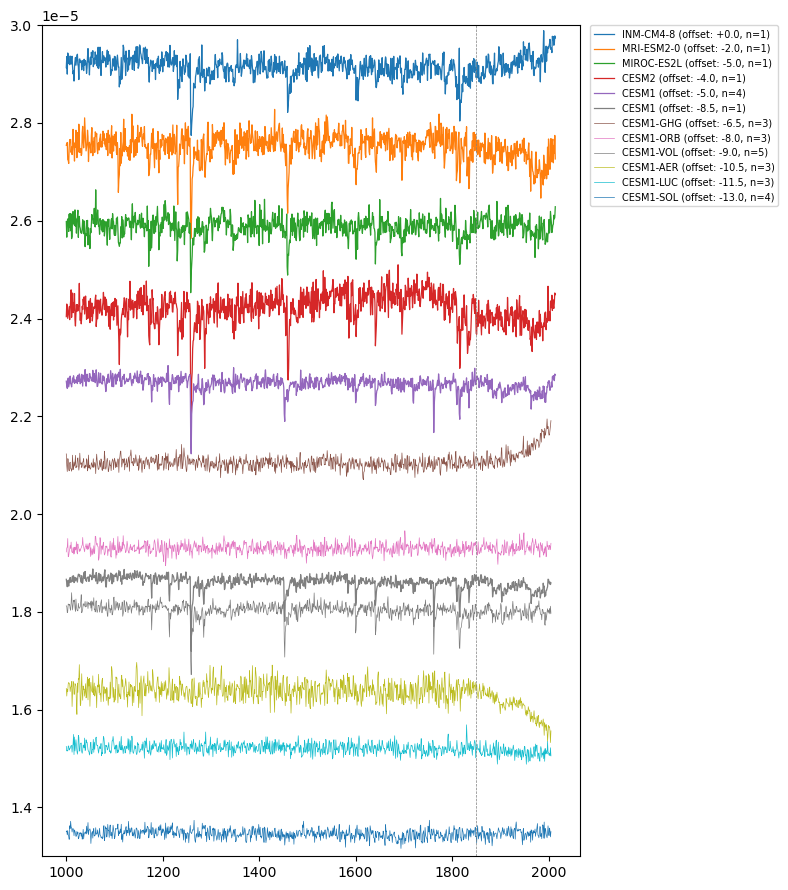

In [15]:
# PRECIPITATION TIME-SERIES
if 'fig'=='fig':
    aa=150; ab=-9
    print(datait_xrq[aa:])
    print(plotdas[0].mean(axis=0)[aa:])
    print(plotdas[6].mean(axis=0)[aa:aa+1015])
    %matplotlib inline
    datait_xrq[950:1000]
    if var=="tas": fc=1
    if var=="pr":  fc=864000
    fig, (ax0) = plt.subplots(nrows=1,figsize=(8,9))
    if var=='tas':ax0.plot(datait_xrq[aa:],plotdas[0].mean(axis=0)[aa:]+0.5/fc,linewidth=0.9,label=modelits[0]+' (offset: +0.5, n=1)')
    if var=='pr': ax0.plot(datait_xrq[aa:],plotdas[0].mean(axis=0)[aa:]+0.0/fc,linewidth=0.9,label=modelits[0]+' (offset: +0.0, n=1)')
    ax0.plot(datait_xrq[aa:],plotdas[1].mean(axis=0)[aa:]-2.0/fc,linewidth=0.9,label=modelits[1]+' (offset: -2.0, n=1)')
    ax0.plot(datait_xrq[aa:],plotdas[2].mean(axis=0)[aa:]-5.0/fc,linewidth=0.9,label=modelits[2]+' (offset: -5.0, n=1)')
    ax0.plot(datait_xrq[aa:],plotdas[3].mean(axis=0)[aa:]-4.0/fc,linewidth=0.9,label=modelits[3]+' (offset: -4.0, n=1)')
    if var=='tas':ax0.plot(datait_xrq[aa:],plotdas[4].mean(axis=0)[aa:]-4.0/fc,linewidth=0.9,label=modelits[4]+' (offset: -4.0, n=4)')
    if var=='pr': ax0.plot(datait_xrq[aa:],plotdas[4].mean(axis=0)[aa:]-5.0/fc,linewidth=0.9,label=modelits[4]+' (offset: -5.0, n=4)')
    if var=='tas':ax0.plot(datait_xrq[aa:ab],plotdas[5].mean(axis=0)[aa:]-5.5/fc,color='grey',linewidth=0.9,label=modelits[5]+' (offset: -5.5, n=1)')
    if var=='pr': ax0.plot(datait_xrq[aa:ab],plotdas[5].mean(axis=0)[aa:]-8.5/fc,color='grey',linewidth=0.9,label=modelits[5]+' (offset: -8.5, n=1)')
    ax0.plot(datait_xrq[aa:ab],plotdas[6].mean(axis=0)[aa:]-6.5/fc,linewidth=0.5,label=modelits[8]+'-GHG (offset: -6.5, n=3)')
    ax0.plot(datait_xrq[aa:ab],plotdas[7].mean(axis=0)[aa:]-8.0/fc,linewidth=0.5,label=modelits[8]+'-ORB (offset: -8.0, n=3)')
    ax0.plot(datait_xrq[aa:ab],plotdas[8].mean(axis=0)[aa:]-9.0/fc,linewidth=0.5,label=modelits[8]+'-VOL (offset: -9.0, n=5)')
    ax0.plot(datait_xrq[aa:ab],plotdas[9].mean(axis=0)[aa:]-10.5/fc,linewidth=0.5,label=modelits[8]+'-AER (offset: -10.5, n=3)')
    ax0.plot(datait_xrq[aa:ab],plotdas[10].mean(axis=0)[aa:]-11.5/fc,linewidth=0.5,label=modelits[8]+'-LUC (offset: -11.5, n=3)')
    if var=='tas':ax0.plot(datait_xrq[aa:ab],plotdas[11].mean(axis=0)[aa:]-13.0/fc,linewidth=0.5,label=modelits[8]+'-SOL (offset: -13.0, n=4)')
    if var=='pr':ax0.plot(datait_xrq[aa:ab],plotdas[11].mean(axis=0)[aa:]-13.0/fc,linewidth=0.5,label=modelits[8]+'-SOL (offset: -13.0, n=4)')
    if var=='tas':ax0.set_ylim(264.5,281)
    if var=='pr':ax0.set_ylim(1.3e-5,3e-5)
    if var=='tas':ax0.plot([datait_xrq[1000],datait_xrq[1000]],[264.5,281],linestyle='dashed',markersize=0,color='0.5',linewidth=0.5,zorder=2)
    if var=='pr':ax0.plot([datait_xrq[1000],datait_xrq[1000]],[1.3e-5,3e-5],linestyle='dashed',markersize=0,color='0.5',linewidth=0.5,zorder=2)
    ax0.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0,fontsize=7)
    #ax1.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0,fontsize=7)
    fig.tight_layout()
    #plt.savefig('Timeseries_data_'+var+'_jas_mean_5models_REVISIONS3_'+Delta+'.png')
    #plt.savefig('Timeseries_data_'+var+'_jas_mean_5models_REVISIONS3_'+Delta+'.pdf')

ik 0 /4
(1165, 54) (54,)
X 4.6841945497213557e-07
Xs 4.6841945497213557e-07 nk= 1
Xcumul 4.6841945497213557e-07 nk= 1
ik 1 /4
(1165, 54) (54,)
X 2.1182298589635449e-07
Xs 6.802424408684901e-07 nk= 2
Xcumul 6.802424408684901e-07 nk= 2
ik 2 /4
(1165, 54) (54,)
X 1.0562262402428431e-06
Xs 1.7364686811113332e-06 nk= 3
Xcumul 1.7364686811113332e-06 nk= 3
ik 3 /4
(1165, 54) (54,)
X -1.366893227447211e-06
Xs 3.6957545366412214e-07 nk= 4
Xcumul 3.6957545366412214e-07 nk= 4
ik 4 /4
(1165, 54) (54,)
X 5.117992163415699e-08
Xs 4.2075537529827913e-07 nk= 5
Xcumul 4.2075537529827913e-07 nk= 5
here
weighted
no projections
univariate_pr_diff_jas_eofs_pcscaling1_coslatyes_diff_5models_REVISIONS.png  eof name figure


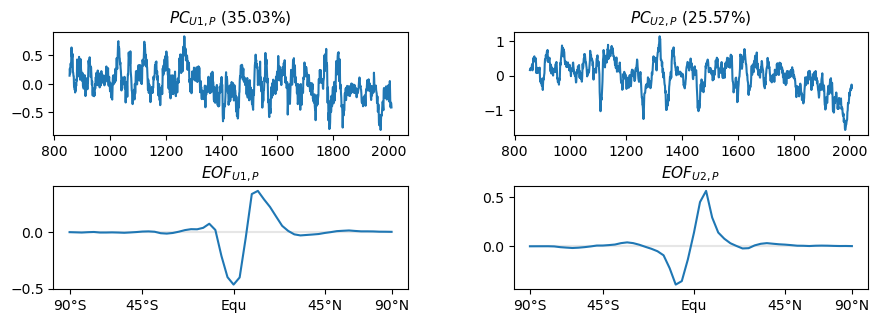

In [16]:
# UNIVARIATE ANALYSIS FOR PR - STEP 10/12 (USING indu='diff')
multiv='no' 

if EOFopt=='eofs':   
 #indu='std'
 indu='diff'
 stdm='PIC'
 #stdm='SEL'
 #if multiv=='no': indu='diff' # best option for pr and tas univariate
 #if multiv=='yes': indu='std' # best option for pr and tas multivariate
 indweight='yes' # best option for tas
 #indweight='no' # best option for pr
 avemodels='yes' # best option for pr and tas univariate
 figname='reve'
 if var=='tas' and multiv=='no' and indu=='diff':figname='univariate_tas_diff'
 if var=='pr' and multiv=='no'and indu=='diff':figname='univariate_pr_diff'
 if var=='tas' and multiv=='no' and indu=='std':figname='univariate_tas_std'
 if var=='pr' and multiv=='no'and indu=='std':figname='univariate_pr_std'
 if var=='pr' and avemodels=='yes' and multiv=='yes':figname='multivariate_tas_pr_std'
 pcsa=0
 Xs=0
 Xsstd=0
 if var=='tas': varname='Temperature' 
 if var=='pr': varname='Precipitation' 
 if multiv=='no':
  fig, axes = plt.subplots(nrows=2,ncols=2, figsize=(9, 5*4/6))
  ax0 = axes[0, 0]
  ax1 = axes[1, 0]
  ax3 = axes[0, 1]
  ax4 = axes[1, 1]
 if multiv=='yes':
  fig, axes = plt.subplots(nrows=3,ncols=2, figsize=(9, 5))
  ax0 = axes[0, 0]
  ax1 = axes[1, 0]
  ax2 = axes[2, 0]
  ax3 = axes[0, 1]
  ax4 = axes[1, 1]
  ax5 = axes[2, 1]
 nk=0
 for ik in range(5):
    print('ik',ik,"/4")
    plotda=plotdas[ik].transpose("time","lat")
    lati  = np.arange(-80, 80, 3)
    plotda=plotda.interp({'lat': lati})
    X=np.array(plotda)
    weights_array=np.cos(np.deg2rad(plotda.lat))[:]; print(X.shape, weights_array.shape)
    #PI
    plotdaPI=plotdaPIs[ik].transpose("time","lat")
    latiPI  = np.arange(-80, 80, 3)
    plotdaPI=plotdaPI.interp({'lat': latiPI})
    XPI=np.array(plotdaPI)
    #PI
    if stdm=='PIC' and indu=='std':  Xstd=np.std(XPI,axis=0); X = (X - np.mean (X, axis=0)) / np.std(XPI, axis=0)
    if stdm=='SEL' and indu=='std':  Xstd=np.std(X,axis=0); X = (X - np.mean (X, axis=0)) / np.std(X, axis=0)
    if var=='tas' and indu=='diff': X = (X - np.mean (X, axis=0))
    if var=='pr'  and indu=='diff': X = (X - np.mean (X, axis=0)) 
    if ik==0: XINM=X 
    if ik==1: XMRI=X
    if ik==2: XMIR=X
    if ik==3: XACC=X 
    if ik==4: XCES=X
    if avemodels=='yes':
        print('X',X[0,0])
        Xs=Xs+np.array(X); nk=nk+1
        print('Xs',Xs[0,0],'nk=',nk)
        X=Xs
        XMRI = xr.DataArray(X, coords={'time':plotda[:].time,'lat': plotda.lat}, dims=["time","lat"])
        if indu=='std':Xsstd=Xsstd+np.array(Xstd); #print('std',Xstd[0])
        modname='5models'
        if var=='tas': mult0=-1; mult1=1
        if var=='pr' and indu=='std': mult0=-1; mult1=-1
        if var=='pr' and indu=='diff': mult0=-1; mult1=-1
    print('Xcumul',X[0,0],'nk=',nk)
    if avemodels=='yes' and ik==0: continue
    if avemodels=='yes' and ik==1: continue
    if avemodels=='yes' and ik==2: continue
    if avemodels=='yes' and ik==3: continue
    Xa=X/nk
    Xstda=Xsstd/nk
    if multiv=='yes':XTASa=XTAS/nk 
    if multiv=='yes':XTASstda=XTASstd/nk 
    if var=='tas'and indweight=='yes':tsolverF0  = Eof(Xa,weights=weights_array) 
    if var=='tas'and indweight=='no':tsolverF0  = Eof(Xa) 
    if var=='pr'and indweight=='no':tsolverF0  = Eof(Xa)
    if var=='pr' and indweight=='yes' : print('here'); tsolverF0  = Eof(Xa,weights=weights_array) ; print('weighted')
    if multiv=='yes':  print('hore',indu); tsolverF0  = MultivariateEof([XTASa[:],Xa[:]],weights=[weights_array,weights_array],center=False)
    if "PROJECTIONS"=="PROJECTIONS":
        print('no projections')
    if multiv=='no':
        meofF0 = tsolverF0.eofs(neofs=3)
        if indu=='std': meofF0 = meofF0*Xstda; print('multiplied by std')
        tpcsF0=tsolverF0.projectField(Xa, neofs=3, eofscaling=1)
        pcsF0 = tsolverF0.pcs(npcs=3,pcscaling=1)
    if multiv=='yes':
        if indu=='std': meofF0 = meofF0*Xstda; print('multiplied by std')
        meofF02, meofF0=tsolverF0.eofs(neofs=3)
        meofF02=meofF02*XTASstda; print('multiplied by std')
        meofF0=meofF0*Xstda; print('multiplied by std')
        pcsF0 = tsolverF0.pcs(npcs=3,pcscaling=1) 
        tpcsF0=tsolverF0.projectField([XTASa,Xa], neofs=3, eofscaling=1)
    pcsF0 = xr.DataArray(pcsF0, coords={'time':plotda[:].time,'numb':list(range(3)) }, dims=["time","numb"])
    tpcsF0 = xr.DataArray(tpcsF0, coords={'time':plotda[:].time,'numb':list(range(3)) }, dims=["time","numb"])
    if 'save_netcdf'=='nosave_netcdf':
     #here save into netcdf
     raise
    varexpF0= tsolverF0.varianceFraction()*100.
    runav=11
    if multiv=='yes': 
        ax1.plot(meofF02[0]*mult0,label='',zorder=2)
        ax2.plot(meofF0[0]*mult0,label='',zorder=2)
        ax0.plot(datait_xrq[:],pcsF0[:,0].rolling(time=runav, center=True).mean('time')*mult0,label='',zorder=2) #+modelits[ik])
    if multiv=='no': 
        ax1.plot(meofF0[0]*mult0,label='',zorder=2)
        ax0.plot(datait_xrq[:],pcsF0[:,0].rolling(time=runav, center=True).mean('time')*mult0,label='',zorder=2) 
    if multiv=='yes': 
        ax4.plot(meofF02[1]*mult1,label='',zorder=2)
        ax5.plot(meofF0[1]*mult1,label='',zorder=2)
        ax3.plot(datait_xrq[:],pcsF0[:,1].rolling(time=runav, center=True).mean('time')*mult1,label='',zorder=2)    
    if multiv=='no': 
        ax4.plot(meofF0[1]*mult1*1,label='',zorder=2)
        ax3.plot(datait_xrq[:],pcsF0[:,1].rolling(time=runav, center=True).mean('time')*mult1*1,label='',zorder=2) 
    x_tick_labels = [u'90\N{DEGREE SIGN}S', u'45\N{DEGREE SIGN}S', u'Equ', u'45\N{DEGREE SIGN}N',u'90\N{DEGREE SIGN}N']
    ax1.set_xticks([findindex(plotda.lat,-90),findindex(plotda.lat,-45),findindex(plotda.lat,0),\
                findindex(plotda.lat,45),findindex(plotda.lat,90)])
    ax1.set_xticklabels(x_tick_labels)
    ax4.set_xticks([findindex(plotda.lat,-90),findindex(plotda.lat,-45),findindex(plotda.lat,0),\
                findindex(plotda.lat,45),findindex(plotda.lat,90)])
    ax4.set_xticklabels(x_tick_labels)
    if multiv=='yes':
        ax2.set_xticks([findindex(plotda.lat,-90),findindex(plotda.lat,-45),findindex(plotda.lat,0),\
                findindex(plotda.lat,45),findindex(plotda.lat,90)])
        ax2.set_xticklabels(x_tick_labels)
        ax5.set_xticks([findindex(plotda.lat,-90),findindex(plotda.lat,-45),findindex(plotda.lat,0),\
                findindex(plotda.lat,45),findindex(plotda.lat,90)])
        ax5.set_xticklabels(x_tick_labels)
    if multiv=='yes':
        ax0.set_title(r'$PC_{M1}$' +' ('+str(round(varexpF0[0],2))+'%)',fontsize=11)
        ax1.set_title(r'$EOF_{M1,T}$',fontsize=11)
        ax2.set_title(r'$EOF_{M1,P}$',fontsize=11)
        ax3.set_title(r'$PC_{M2}$' +' ('+str(round(varexpF0[1],2))+'%)',fontsize=11)
        ax4.set_title(r'$EOF_{M2,T}$',fontsize=11)
        ax5.set_title(r'$EOF_{M2,P}$',fontsize=11)
    if multiv=='no':
        ax0.set_title(r'$PC_{U1,'+varname[0]+'}$' +' ('+str(round(varexpF0[0],2))+'%)',fontsize=11)
        ax1.set_title(r'$EOF_{U1,'+varname[0]+'}$',fontsize=11)
        ax3.set_title(r'$PC_{U2,'+varname[0]+'}$' +' ('+str(round(varexpF0[1],2))+'%)',fontsize=11)
        ax4.set_title(r'$EOF_{U2,'+varname[0]+'}$',fontsize=11)
    ax1.plot(meofF0[1]*0,color='0.9',zorder=1)
    if multiv=='yes':ax2.plot(meofF0[1]*0,color='0.9',zorder=1)
    ax4.plot(meofF0[1]*0,color='0.9',zorder=1)
    if multiv=='yes':ax5.plot(meofF0[1]*0,color='0.9',zorder=1)
    plt.subplots_adjust(bottom=0.05, right=0.9, top=0.94,hspace=0.29)
    print(figname+'_jas_eofs_pcscaling1_coslat'+indweight+'_'+indu+'_'+modname+'_REVISIONS.png',' eof name figure')
    fig.tight_layout()
    fig.subplots_adjust(hspace=0.5, wspace=0.3)
    #plt.savefig('FINALREV_'+str(runav)+'_'+figname+'_5models_jas_eofs_pcscaling1_coslat'+indweight+'_'+indu+'_'+modname+'_REVISIONS3'+stdm+'_'+Delta+'.png')
    #plt.savefig('FINALREV_'+str(runav)+'_'+figname+'_5models_jas_eofs_pcscaling1_coslat'+indweight+'_'+indu+'_'+modname+'_REVISIONS3'+stdm+'_'+Delta+'.pdf')

if multiv=='no' and var=='pr' and indu=='diff':
    ni_PC0_prd_1=pcsF0[:,0].rolling(time=1, center=True).mean('time')*mult0
    ni_PC1_prd_1=pcsF0[:,1].rolling(time=1, center=True).mean('time')*mult1
    ni_PC0_prd_3=pcsF0[:,0].rolling(time=3, center=True).mean('time')*mult0
    ni_PC1_prd_3=pcsF0[:,1].rolling(time=3, center=True).mean('time')*mult1
    ni_PC0_prd_5=pcsF0[:,0].rolling(time=5, center=True).mean('time')*mult0
    ni_PC1_prd_5=pcsF0[:,1].rolling(time=5, center=True).mean('time')*mult1
    ni_PC0_prd_11=pcsF0[:,0].rolling(time=11, center=True).mean('time')*mult0
    ni_PC1_prd_11=pcsF0[:,1].rolling(time=11, center=True).mean('time')*mult1


ik 0 /4
(1165, 54) (54,)
X 0.7415397475672221
Xs 0.7415397475672221 nk= 1
Xcumul 0.7415397475672221 nk= 1
ik 1 /4
(1165, 54) (54,)
X 0.389827035950816
Xs 1.131366783518038 nk= 2
Xcumul 1.131366783518038 nk= 2
ik 2 /4
(1165, 54) (54,)
X 1.3668173038715474
Xs 2.4981840873895855 nk= 3
Xcumul 2.4981840873895855 nk= 3
ik 3 /4
(1165, 54) (54,)
X -1.956334382864447
Xs 0.5418497045251385 nk= 4
Xcumul 0.5418497045251385 nk= 4
ik 4 /4
(1165, 54) (54,)
X 0.12200823238279757
Xs 0.663857936907936 nk= 5
Xcumul 0.663857936907936 nk= 5
here
weighted
hore std
ikY 0 /11
ikY 1 /11
ikY 2 /11
ikY 3 /11
ikY 4 /11
ikY 5 /11
ikY 6 /11
ikY 7 /11
ikY 8 /11
ikY 9 /11
ikY 10 /11
ikY 11 /11
multiplied by std
multiplied by std
multiplied by std
multivariate_tas_pr_std_jas_eofs_pcscaling1_coslatyes_std_5models_REVISIONS.png  eof name figure


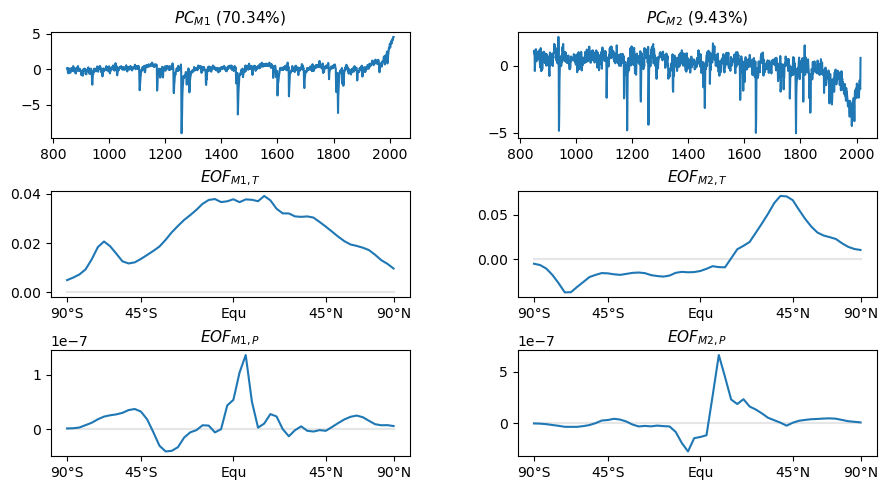

In [17]:
# MULTIVARIATE ANALYSIS USING XTAS AND X(PR) - STEP 11/12 (USING indu='std')
multiv='yes' 

if EOFopt=='eofs':   
 indu='std'
 #indu='diff'
 stdm='PIC'
 #stdm='SEL'
 #if multiv=='no': indu='diff' # best option for pr and tas univariate
 #if multiv=='yes': indu='std' # best option for pr and tas multivariate
 indweight='yes' # best option for tas
 #indweight='no' # best option for pr
 avemodels='yes' # best option for pr and tas univariate
 figname='reve'
 if var=='tas' and multiv=='no' and indu=='diff':figname='univariate_tas_diff'
 if var=='pr' and multiv=='no'and indu=='diff':figname='univariate_pr_diff'
 if var=='tas' and multiv=='no' and indu=='std':figname='univariate_tas_std'
 if var=='pr' and multiv=='no'and indu=='std':figname='univariate_pr_std'
 if var=='pr' and avemodels=='yes' and multiv=='yes':figname='multivariate_tas_pr_std'
 pcsa=0
 Xs=0
 Xsstd=0
 if var=='tas': varname='Temperature' 
 if var=='pr': varname='Precipitation' 
 if multiv=='no':
  fig, axes = plt.subplots(nrows=2,ncols=2, figsize=(9, 5*4/6))
  ax0 = axes[0, 0]
  ax1 = axes[1, 0]
  ax3 = axes[0, 1]
  ax4 = axes[1, 1]
 if multiv=='yes':
  fig, axes = plt.subplots(nrows=3,ncols=2, figsize=(9, 5))
  ax0 = axes[0, 0]
  ax1 = axes[1, 0]
  ax2 = axes[2, 0]
  ax3 = axes[0, 1]
  ax4 = axes[1, 1]
  ax5 = axes[2, 1]
 nk=0
 for ik in range(5):
    print('ik',ik,"/4")
    plotda=plotdas[ik].transpose("time","lat")
    lati  = np.arange(-80, 80, 3)
    plotda=plotda.interp({'lat': lati})
    X=np.array(plotda)
    weights_array=np.cos(np.deg2rad(plotda.lat))[:]; print(X.shape, weights_array.shape)
    #PI
    plotdaPI=plotdaPIs[ik].transpose("time","lat")
    latiPI  = np.arange(-80, 80, 3)
    plotdaPI=plotdaPI.interp({'lat': latiPI})
    XPI=np.array(plotdaPI)
    #PI
    if stdm=='PIC' and indu=='std':  Xstd=np.std(XPI,axis=0); X = (X - np.mean (X, axis=0)) / np.std(XPI, axis=0)
    if stdm=='SEL' and indu=='std':  Xstd=np.std(X,axis=0); X = (X - np.mean (X, axis=0)) / np.std(X, axis=0)
    if var=='tas' and indu=='diff': X = (X - np.mean (X, axis=0))
    if var=='pr'  and indu=='diff': X = (X - np.mean (X, axis=0)) 
    if ik==0: XINM=X 
    if ik==1: XMRI=X
    if ik==2: XMIR=X
    if ik==3: XACC=X 
    if ik==4: XCES=X
    if avemodels=='yes':
        print('X',X[0,0])
        Xs=Xs+np.array(X); nk=nk+1
        print('Xs',Xs[0,0],'nk=',nk)
        X=Xs
        XMRI = xr.DataArray(X, coords={'time':plotda[:].time,'lat': plotda.lat}, dims=["time","lat"])
        #print(XMRI[30,10])
        if indu=='std':Xsstd=Xsstd+np.array(Xstd); #print('std',Xstd[0])
        modname='5models'
        if var=='tas': mult0=-1; mult1=1
        if var=='pr' and indu=='std': mult0=-1; mult1=-1
        if var=='pr' and indu=='diff': mult0=-1; mult1=-1
    print('Xcumul',X[0,0],'nk=',nk)
    if avemodels=='yes' and ik==0: continue
    if avemodels=='yes' and ik==1: continue
    if avemodels=='yes' and ik==2: continue
    if avemodels=='yes' and ik==3: continue
    Xa=X/nk
    Xstda=Xsstd/nk
    if multiv=='yes':XTASa=XTAS/nk 
    if multiv=='yes':XTASstda=XTASstd/nk 
    if var=='tas'and indweight=='yes':tsolverF0  = Eof(Xa,weights=weights_array) 
    if var=='tas'and indweight=='no':tsolverF0  = Eof(Xa) 
    if var=='pr'and indweight=='no':tsolverF0  = Eof(Xa)
    if var=='pr' and indweight=='yes' : print('here'); tsolverF0  = Eof(Xa,weights=weights_array) ; print('weighted')
    if multiv=='yes':  print('hore',indu); tsolverF0  = MultivariateEof([XTASa[:],Xa[:]],weights=[weights_array,weights_array],center=False)
    if "PROJECTIONS"=="PROJECTIONS":
     if var=='tas' and multiv=='no': YTAS4MULT=[]
     if var=='pr' and multiv=='no':  YPR4MULT=[]
     if var=='pr' and multiv=='yes':  YPR4MULT=[]
     for ikY in range(0,12,1):
        print('ikY',ikY,"/11")
        plotdaY=plotdas[ikY].transpose("time","lat")
        if ikY==0:plotdaYPI=plotdaPIs[0].transpose("time","lat")
        if ikY==1:plotdaYPI=plotdaPIs[1].transpose("time","lat")
        if ikY==2:plotdaYPI=plotdaPIs[2].transpose("time","lat")
        if ikY==3:plotdaYPI=plotdaPIs[3].transpose("time","lat")
        if ikY==4:plotdaYPI=plotdaPIs[4].transpose("time","lat")
        if ikY>4:plotdaYPI=plotdaPIs[4].transpose("time","lat")
        lati  = np.arange(-80, 80, 3)
        plotdaY=plotdaY.interp({'lat': lati})
        plotdaYPI=plotdaYPI.interp({'lat': lati})
        Y=np.array(plotdaY)
        YPI=np.array(plotdaYPI)
        weights_array=np.cos(np.deg2rad(plotdaY.lat))[:]
        if stdm=='SEL' and indu=='std':  Ystd=np.std(Y,axis=0); Y = (Y - np.mean (Y, axis=0)) / np.std(Y, axis=0)
        if stdm=='PIC' and indu=='std':  Ystd=np.std(YPI,axis=0); Y = (Y - np.mean (Y, axis=0)) / np.std(YPI, axis=0)
        if var=='tas' and indu=='diff': Y = (Y - np.mean (Y, axis=0))
        if var=='pr'  and indu=='diff': Y = (Y - np.mean (Y, axis=0)) 
        if var=='tas':YTAS4MULT.append(Y)
        if var=='pr':YPR4MULT.append(Y)
    if multiv=='no':
        meofF0 = tsolverF0.eofs(neofs=3)
        if indu=='std': meofF0 = meofF0*Xstda; print('multiplied by std')
        tpcsF0=tsolverF0.projectField(Xa, neofs=3, eofscaling=1)
        pcsF0 = tsolverF0.pcs(npcs=3,pcscaling=1)
    if multiv=='yes':
        if indu=='std': meofF0 = meofF0*Xstda; print('multiplied by std')
        meofF02, meofF0=tsolverF0.eofs(neofs=3)
        meofF02=meofF02*XTASstda; print('multiplied by std')
        meofF0=meofF0*Xstda; print('multiplied by std')
        pcsF0 = tsolverF0.pcs(npcs=3,pcscaling=1) 
        tpcsF0=tsolverF0.projectField([XTASa,Xa], neofs=3, eofscaling=1)
    #print('same?')
    #print('PC',pcsF0[0:5])
    #print('project',tpcsF0[0:5])
    pcsF0 = xr.DataArray(pcsF0, coords={'time':plotda[:].time,'numb':list(range(3)) }, dims=["time","numb"])
    tpcsF0 = xr.DataArray(tpcsF0, coords={'time':plotda[:].time,'numb':list(range(3)) }, dims=["time","numb"])
    if 'save_netcdf'=='nosave_netcdf':
     #here save into netcdf
     pcsF0sv=pcsF0*1.
     pcsF0sv[:,0]=pcsF0[:,0]*mult0
     pcsF0sv[:,1]=pcsF0[:,1]*mult1
     pcsF0sv.attrs['_FillValue'] = float(1.e+20)
     pcsF0sv.attrs['missing_value'] = float(1.e+20)
     pcsF0sv.attrs['units'] = ''
     pcsF0sv.attrs['long_name'] = 'Principal Components'
     pcsF0sv.attrs['standard_name'] = 'pcs'
     pcsF0sv.time.attrs['_FillValue'] = float(1.e+20)
     filenamepc=figname+'_multivariate_5models_jas_pcs_pcscaling1_coslat_past1000_'+indweight+'_'+indu+str(ik)+'_'+modname+'_Amon_gr_185001-201412-REVct'+stdm+'.nc'
     pcsF0sv[:,0].to_dataset(name='pcsF0').to_netcdf(filenamepc,unlimited_dims="time")
     pcsF0sv[:,1].to_dataset(name='pcsF1').to_netcdf(filenamepc,unlimited_dims="time",mode='a')
     pcsF0sv[:,0].rolling(time=1, center=True).mean('time').to_dataset(name='pcsF0_1roll').to_netcdf(filenamepc,unlimited_dims="time",mode='a')
     pcsF0sv[:,1].rolling(time=1, center=True).mean('time').to_dataset(name='pcsF1_1roll').to_netcdf(filenamepc,unlimited_dims="time",mode='a')
     pcsF0sv[:,0].rolling(time=3, center=True).mean('time').to_dataset(name='pcsF0_3roll').to_netcdf(filenamepc,unlimited_dims="time",mode='a')
     pcsF0sv[:,1].rolling(time=3, center=True).mean('time').to_dataset(name='pcsF1_3roll').to_netcdf(filenamepc,unlimited_dims="time",mode='a')
     pcsF0sv[:,0].rolling(time=5, center=True).mean('time').to_dataset(name='pcsF0_5roll').to_netcdf(filenamepc,unlimited_dims="time",mode='a')
     pcsF0sv[:,1].rolling(time=5, center=True).mean('time').to_dataset(name='pcsF1_5roll').to_netcdf(filenamepc,unlimited_dims="time",mode='a')
     pcsF0sv[:,0].rolling(time=11, center=True).mean('time').to_dataset(name='pcsF0_11roll').to_netcdf(filenamepc,unlimited_dims="time",mode='a')
     pcsF0sv[:,1].rolling(time=11, center=True).mean('time').to_dataset(name='pcsF1_11roll').to_netcdf(filenamepc,unlimited_dims="time",mode='a')
     meofF0sv = xr.DataArray(meofF0, coords={'ind':list(range(3)),'lat': plotda.lat}, dims=["ind","lat"])
     meofF0sv[0]=meofF0sv[0]*mult0
     meofF0sv[1]=meofF0sv[1]*mult1
     meofF0sv.attrs['_FillValue'] = float(1.e+20)
     meofF0sv.attrs['missing_value'] = float(1.e+20)
     meofF0sv.attrs['units'] = ''
     meofF0sv.attrs['long_name'] = 'Empirical Orthogonal Functions'
     meofF0sv.attrs['standard_name'] = 'eofs'
     filename=figname+'_'+var+'_5models_jas_eofs_pcscaling1_coslat_past1000_'+indweight+'_'+indu+str(ik)+'_'+modname+'_Amon_gr_185001-201412_REVct'+stdm+'.nc'
     meofF0sv[0].to_dataset(name='meofF0').to_netcdf(filename)
     meofF0sv[1].to_dataset(name='meofF1').to_netcdf(filename,mode='a')
     raise
    varexpF0= tsolverF0.varianceFraction()*100.
    #runav=11
    #runav=5
    runav=1
    if multiv=='yes': 
        ax1.plot(meofF02[0]*mult0,label='',zorder=2)
        ax2.plot(meofF0[0]*mult0,label='',zorder=2)
        ax0.plot(datait_xrq[:],pcsF0[:,0].rolling(time=runav, center=True).mean('time')*mult0,label='',zorder=2) #+modelits[ik])
    if multiv=='no': 
        ax1.plot(meofF0[0]*mult0,label='',zorder=2)
        ax0.plot(datait_xrq[:],pcsF0[:,0].rolling(time=runav, center=True).mean('time')*mult0,label='',zorder=2) 
    if multiv=='yes': 
        ax4.plot(meofF02[1]*mult1,label='',zorder=2)
        ax5.plot(meofF0[1]*mult1,label='',zorder=2)
        ax3.plot(datait_xrq[:],pcsF0[:,1].rolling(time=runav, center=True).mean('time')*mult1,label='',zorder=2)    
    if multiv=='no': 
        ax4.plot(meofF0[1]*mult1*1,label='',zorder=2)
        ax3.plot(datait_xrq[:],pcsF0[:,1].rolling(time=runav, center=True).mean('time')*mult1*1,label='',zorder=2) 
    x_tick_labels = [u'90\N{DEGREE SIGN}S', u'45\N{DEGREE SIGN}S', u'Equ', u'45\N{DEGREE SIGN}N',u'90\N{DEGREE SIGN}N']
    ax1.set_xticks([findindex(plotda.lat,-90),findindex(plotda.lat,-45),findindex(plotda.lat,0),\
                findindex(plotda.lat,45),findindex(plotda.lat,90)])
    ax1.set_xticklabels(x_tick_labels)
    ax4.set_xticks([findindex(plotda.lat,-90),findindex(plotda.lat,-45),findindex(plotda.lat,0),\
                findindex(plotda.lat,45),findindex(plotda.lat,90)])
    ax4.set_xticklabels(x_tick_labels)
    if multiv=='yes':
        ax2.set_xticks([findindex(plotda.lat,-90),findindex(plotda.lat,-45),findindex(plotda.lat,0),\
                findindex(plotda.lat,45),findindex(plotda.lat,90)])
        ax2.set_xticklabels(x_tick_labels)
        ax5.set_xticks([findindex(plotda.lat,-90),findindex(plotda.lat,-45),findindex(plotda.lat,0),\
                findindex(plotda.lat,45),findindex(plotda.lat,90)])
        ax5.set_xticklabels(x_tick_labels)
    if multiv=='yes':
        ax0.set_title(r'$PC_{M1}$' +' ('+str(round(varexpF0[0],2))+'%)',fontsize=11)
        ax1.set_title(r'$EOF_{M1,T}$',fontsize=11)
        ax2.set_title(r'$EOF_{M1,P}$',fontsize=11)
        ax3.set_title(r'$PC_{M2}$' +' ('+str(round(varexpF0[1],2))+'%)',fontsize=11)
        ax4.set_title(r'$EOF_{M2,T}$',fontsize=11)
        ax5.set_title(r'$EOF_{M2,P}$',fontsize=11)
    if multiv=='no':
        ax0.set_title(r'$PC_{U1,'+varname[0]+'}$' +' ('+str(round(varexpF0[0],2))+'%)',fontsize=11)
        ax1.set_title(r'$EOF_{U1,'+varname[0]+'}$',fontsize=11)
        ax3.set_title(r'$PC_{U2,'+varname[0]+'}$' +' ('+str(round(varexpF0[1],2))+'%)',fontsize=11)
        ax4.set_title(r'$EOF_{U2,'+varname[0]+'}$',fontsize=11)
    ax1.plot(meofF0[1]*0,color='0.9',zorder=1)
    if multiv=='yes':ax2.plot(meofF0[1]*0,color='0.9',zorder=1)
    ax4.plot(meofF0[1]*0,color='0.9',zorder=1)
    if multiv=='yes':ax5.plot(meofF0[1]*0,color='0.9',zorder=1)
    plt.subplots_adjust(bottom=0.05, right=0.9, top=0.94,hspace=0.29)
    print(figname+'_jas_eofs_pcscaling1_coslat'+indweight+'_'+indu+'_'+modname+'_REVISIONS.png',' eof name figure')
    fig.tight_layout()
    fig.subplots_adjust(hspace=0.5, wspace=0.3)
    #plt.savefig('FINALREV_'+str(runav)+'_'+figname+'_5models_jas_eofs_pcscaling1_coslat'+indweight+'_'+indu+'_'+modname+'_REVISIONS3'+stdm+'_'+Delta+'.png')
    #plt.savefig('FINALREV_'+str(runav)+'_'+figname+'_5models_jas_eofs_pcscaling1_coslat'+indweight+'_'+indu+'_'+modname+'_REVISIONS3'+stdm+'_'+Delta+'.pdf')

if multiv=='yes' and var=='pr' and indu=='std':
    mu_PC0_std_1=pcsF0[:,0].rolling(time=1, center=True).mean('time')*mult0
    mu_PC1_std_1=pcsF0[:,1].rolling(time=1, center=True).mean('time')*mult1
    mu_PC0_std_3=pcsF0[:,0].rolling(time=3, center=True).mean('time')*mult0
    mu_PC1_std_3=pcsF0[:,1].rolling(time=3, center=True).mean('time')*mult1
    mu_PC0_std_5=pcsF0[:,0].rolling(time=5, center=True).mean('time')*mult0
    mu_PC1_std_5=pcsF0[:,1].rolling(time=5, center=True).mean('time')*mult1
    mu_PC0_std_11=pcsF0[:,0].rolling(time=11, center=True).mean('time')*mult0
    mu_PC1_std_11=pcsF0[:,1].rolling(time=11, center=True).mean('time')*mult1

2026-05-27 14:00:42,908 [WARNING]: dataset.py(_preprocess:458) >> "No time coordinates were found in this dataset to decode. If time coordinates were expected to exist, make sure they are detectable by setting the CF 'axis' or 'standard_name' attribute (e.g., ds['time'].attrs['axis'] = 'T' or ds['time'].attrs['standard_name'] = 'time'). Afterwards, try decoding again with `xcdat.decode_time`."
2026-05-27 14:00:42,908 [WARNING]: dataset.py(_preprocess:458) >> "No time coordinates were found in this dataset to decode. If time coordinates were expected to exist, make sure they are detectable by setting the CF 'axis' or 'standard_name' attribute (e.g., ds['time'].attrs['axis'] = 'T' or ds['time'].attrs['standard_name'] = 'time'). Afterwards, try decoding again with `xcdat.decode_time`."


None
<xarray.Dataset> Size: 20kB
Dimensions:          (Year: 1015)
Coordinates:
  * Year             (Year) int32 4kB 1000 1001 1002 1003 ... 2012 2013 2014
Data variables:
    Annual_SAOD_Sum  (Year) float64 8kB dask.array<chunksize=(1015,), meta=np.ndarray>
    Ti               (Year) float64 8kB dask.array<chunksize=(1015,), meta=np.ndarray>
multivariate_tas_pr_std std -1 -1 pr
muiPC0
0.99 0.12 0.67
muiPC1
0.99 0.52 0.51
<xarray.DataArray 'time' (time: 1005)> Size: 8kB
array([cftime.DatetimeNoLeap(1005, 8, 1, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(1006, 8, 1, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(1007, 8, 1, 0, 0, 0, 0, has_year_zero=True), ...,
       cftime.DatetimeNoLeap(2007, 8, 1, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(2008, 8, 1, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(2009, 8, 1, 0, 0, 0, 0, has_year_zero=True)],
      shape=(1005,), dtype=object)
Coordinates:
  * time     (time) objec

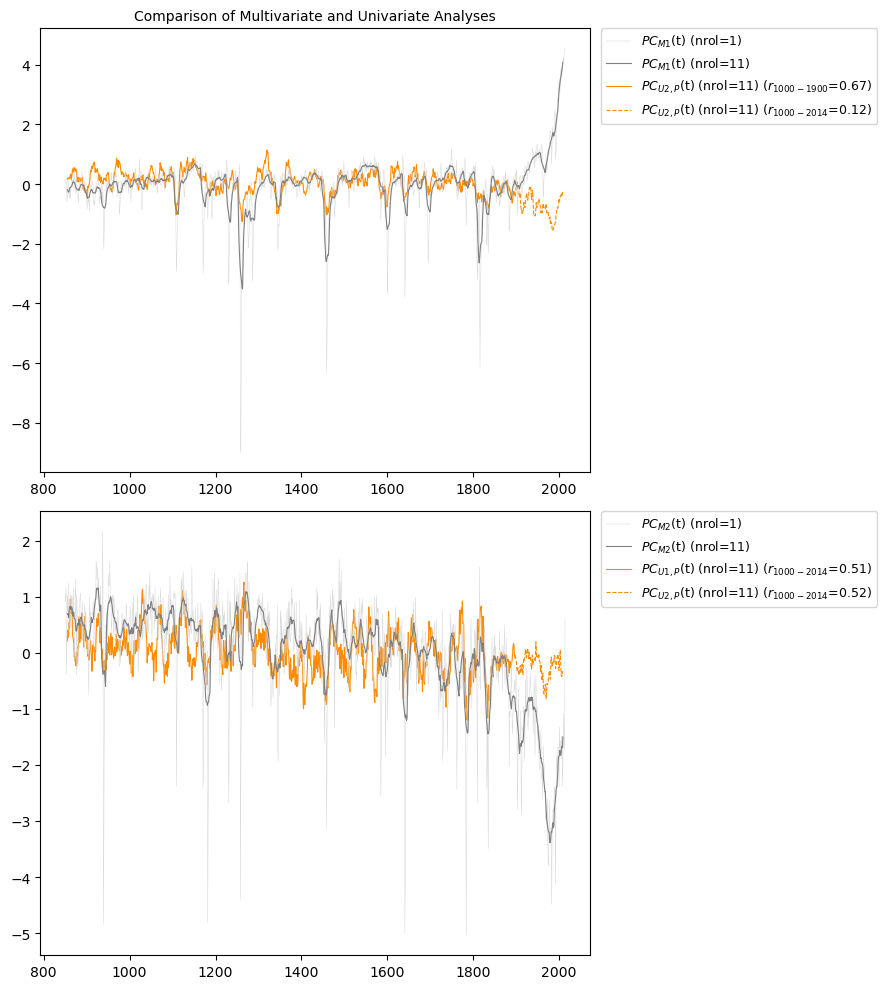

In [18]:
def trendTi(datafi):
    yearsfic = np.arange(1010, 1950+adji) 
    print(datafi.shape, yearsfic.shape)
    datafic = datafi
    timefic = xr.DataArray(yearsfic, dims="time", name="time")
    data_arrayfic = xr.DataArray(datafic, dims="time", coords={"time": timefic}, name="data")
    slopefic, interceptfic, _, _, _ = scipy.stats.linregress(yearsfic, data_arrayfic.values)#
    trendfic = slopefic * yearsfic + interceptfic
    return trendfic

filenameti="/global/cfs/projectdirs/m4581/bonfils2/bonfils2/Downloads/SAOD_annual_sum_Ti2.nc"
dsTi=xc.open_mfdataset(filenameti) #,add_bounds=('X','Y'),decode_times=True,center_times=True)
print(dsTi.encoding.get('source', None))
print(dsTi)
Ti=dsTi["Ti"]
yearsTi = np.arange(1000, 2015) 
years = np.arange(1000, 2015) 
timeTi = xr.DataArray(yearsTi, dims="time", name="time")
Ti = xr.DataArray(Ti, dims="time", coords={"time": timeTi}, name="data")
SAO=dsTi["Annual_SAOD_Sum"]
SAOD = xr.DataArray(SAO, dims=["time"], coords={"time": years}, name="values")

print(figname, indu, mult0,mult1,var)

if 'save_netcdf'=='nosave_netcdf':
     #pcsF0sv=pcsF0*1.
     mu_PC1_std_1.attrs['_FillValue'] = float(1.e+20)
     mu_PC1_std_1.attrs['missing_value'] = float(1.e+20)
     mu_PC1_std_1.attrs['units'] = ''
     mu_PC1_std_1.attrs['long_name'] = 'Principal Components'
     mu_PC1_std_1.attrs['standard_name'] = 'pcs'
     mu_PC1_std_1.time.attrs['_FillValue'] = float(1.e+20)
     filenamemu='/global/cfs/projectdirs/m4581/bonfils2/bonfils2/Downloads/mu_PC1_std_1.nc'
     mu_PC1_std_1.to_dataset(name='mu_PC1_std_1').to_netcdf(filenamemu)
     #meofF0sv[1].to_dataset(name='meofF1').to_netcdf(filename,mode='a')

if multiv=='yes' and var=='pr' and indu=='std':
 if 'figunimulti'=='figunimulti':
    print('muiPC0')
    mui0_tas=str(round(genutil.statistics.correlation(mu_PC0_std_11[155:-5],ni_PC0_tasd_11[155:-5]).data*1.,2))
    mui0_prall=str(round(genutil.statistics.correlation(mu_PC0_std_11[155:-5],ni_PC1_prd_11[155:-5]).data*1.,2))
    mui0_prcourt=str(round(genutil.statistics.correlation(mu_PC0_std_11[155:-5-112],ni_PC1_prd_11[155:-5-112]).data*1.,2))
    print(mui0_tas, mui0_prall, mui0_prcourt)
    #print(str(round(genutil.statistics.correlation(mu_PC0_std[-112:],ni_PC1_prd[-112:]).data*1.,2)))
    print('muiPC1')
    mui1_tas=str(round(genutil.statistics.correlation(mu_PC1_std_11[155:-5],ni_PC1_tasd_11[155:-5]).data*1.,2))
    mui1_prall=str(round(genutil.statistics.correlation(mu_PC1_std_11[155:-5],ni_PC0_prd_11[155:-5]).data*1.,2))
    mui1_prcourt=str(round(genutil.statistics.correlation(mu_PC1_std_11[155:-5-112],ni_PC0_prd_11[155:-5-112:]).data*1.,2))
    print(mui1_tas, mui1_prall, mui1_prcourt)
    print(mu_PC1_std_11[155:-5]['time'],mu_PC1_std_11[155:-5-112]['time'])

if multiv=='yes' and var=='pr' and indu=='std':
    nrol=3; nroa=int((nrol-1)/2)
    #nrol=1; nroa=1
    adji=-30
    dqi=1100+adji
    dwi=950+adji
    periodtr='1000-'+str(1950+adji)
    mu_PC1da=mu_PC1_std_3
    mu_PC1da1=mu_PC1_std_1

if multiv=='yes' and var=='pr' and indu=='std':
    print('here')
    print(mu_PC1da[150+10-nroa:dqi+nroa]['time'])
    print(Ti[10-nroa:dwi+nroa]['time'])
    trendmu=trendTi(mu_PC1da[150+10-nroa:dqi+nroa].rolling(time=nrol,center=True).mean('time')[nroa:-nroa])
    trendmu1=trendTi(mu_PC1da1[150+10-nroa:dqi+nroa].rolling(time=nrol,center=True).mean('time')[nroa:-nroa])
    trendTit=trendTi(Ti[10-nroa:dwi+nroa].rolling(time=nrol,center=True).mean('time')[nroa:-nroa])

if 'figtrends'=='NOfigtrends':
    data1=(mu_PC1da[160:][nroa:-nroa])
    data2=(Ti[10:].rolling(time=nrol,center=True).mean('time')[nroa:-nroa])
    data3=(SAOD[10:][nroa:-nroa]*-1)
    print('data1',data1['time'])
    print('data2',data2['time'])
    print('data3',data3['time'])
    print('COR PC1/SAOD',str(genutil.statistics.correlation(data1,data3)))
    print('COR Ti/SAOD',str(genutil.statistics.correlation(data2,data3)))
    print('COR PC1/Ti',str(genutil.statistics.correlation(data1,data2)))
    cPC1Ti=str(round(genutil.statistics.correlation(data1,data2).data*1.,2))
    print(cPC1Ti, mu_PC1da[160:][nroa:-nroa]['time'])
    data1=(mu_PC1da[160:dqi]-trendmu[:])[nroa:-nroa]*1.
    data11=(mu_PC1da1[160:dqi]-trendmu1[:])[nroa:-nroa]*1.
    data2=(Ti[10:dwi].rolling(time=nrol,center=True).mean('time')-trendTit[:])[nroa:-nroa]*1.
    data3=(SAOD[10:dwi][nroa:-nroa]*-1)
    #concatvolaer=mu_PC1da[:-9]*0.
    #concatvolaer[:1000]=projvol[:1000,1]
    #concatvolaer[1000:]=projaer[1000:,1]
    print('data1',data1['time'])
    print('data2',data2['time'])
    print('data3',data3['time'])
    print('CORdet PC1/SAOD',str(genutil.statistics.correlation(data11,data3)))
    print('CORdet Ti/SAOD',str(genutil.statistics.correlation(data2,data3)))
    print('CORdet PC1/Ti',str(genutil.statistics.correlation(data1,data2)))
    cPC1dSAOD=str(round(genutil.statistics.correlation(data11,data3).data*1.,2))
    cPC1dTid=str(round(genutil.statistics.correlation(data1,data2).data*1.,2))
    print(cPC1dSAOD)
    print(cPC1dTid)

if 'figunimulti'=='figunimulti':
    fig, (axx0,axx1) = plt.subplots(nrows=2,figsize=(9,10))
    axx0.plot(datait_xrq[:],mu_PC0_std_1[:],color='lightgrey',linestyle='-',marker='None',markersize=0,linewidth=0.3,zorder=3,label=r'$PC_{M1}$(t) (nrol=1)')
    axx0.plot(datait_xrq[:],mu_PC0_std_11[:],color='grey',linestyle='-',marker='None',markersize=0,linewidth=0.8,zorder=3,label=r'$PC_{M1}$(t) (nrol=11)')
    axx0.plot(datait_xrq[:-117],ni_PC1_prd_11[:-117],color='darkorange',linestyle='-',marker='None',markersize=0,linewidth=0.8,zorder=1, label=r'$PC_{U2,P}$(t) (nrol=11) (' +r'$r_{1000-1900}$='+ mui0_prcourt+')')
    axx0.plot(datait_xrq[-117:],ni_PC1_prd_11[-117:],color='darkorange',linestyle='--',marker='None',markersize=0,linewidth=0.8,zorder=2,label=r'$PC_{U2,P}$(t) (nrol=11) (' +r'$r_{1000-2014}$='+ mui0_prall+')')
    ####axx0.plot(datait_xrq[:],ni_PC1_prd_11[:],color='lightblue',linewidth=0.3,zorder=0,label=r'$PC_{U2,Precipitation}$ - no filter')
    axx1.plot(datait_xrq[:],mu_PC1_std_1[:],color='lightgrey',linestyle='-',marker='None',markersize=0,linewidth=0.3,zorder=3,label=r'$PC_{M2}$(t) (nrol=1)')
    axx1.plot(datait_xrq[:],mu_PC1_std_11[:],color='grey',linestyle='-',marker='None',markersize=0,linewidth=0.8,zorder=3,label=r'$PC_{M2}$(t) (nrol=11)')
    axx1.plot(datait_xrq[:-117],ni_PC0_prd_11[:-117]*1.5,color='darkorange',linestyle='-',marker='None',markersize=0,linewidth=0.8,zorder=2,label=r'$PC_{U1,P}$(t) (nrol=11) (' +r'$r_{1000-2014}$='+ mui1_prcourt+')')
    axx1.plot(datait_xrq[-117:],ni_PC0_prd_11[-117:],color='darkorange',linestyle='--',marker='None',markersize=0,linewidth=0.8,zorder=2,label=r'$PC_{U2,P}$(t) (nrol=11) (' +r'$r_{1000-2014}$='+ mui1_prall+')')
    #axx1.plot(datait_xrq[:-117],ni_PC0_prd_11[:-117]*2,color='darkorange',linestyle='--',marker='None',markersize=0,linewidth=1,zorder=2,label=r'$PC_{U1,Precipitation}$ (r='+ mui1_prcourt+')')
    #axx1.plot(datait_xrq[:],ni_PC0_prd_11[:],color='lightblue',linewidth=0.3,zorder=0,label=r'$PC_{U1,Precipitation}$ - no filter')
    axx0.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0,fontsize=9)
    axx1.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0,fontsize=9)
    axx0.set_title('Comparison of Multivariate and Univariate Analyses',fontsize=10)
    print('FINALREV_multi_versus_uni_5models_jas_eofs_pcscaling1_coslat'+indweight+'_'+indu+'_'+modname+'_REVISIONS')
    fig.subplots_adjust(hspace=0.5, wspace=0.3)
    fig.tight_layout()
    #plt.savefig('FINALREV_multi_versus_uni_5models_jas_eofs_pcscaling1_coslat'+indweight+'_'+indu+'_'+modname+'_REVISIONS4.png')
    #plt.savefig('FINALREV_multi_versus_uni_5models_jas_eofs_pcscaling1_coslat'+indweight+'_'+indu+'_'+modname+'_REVISIONS4.pdf')

if 'figtrends'=='NOfigtrends':
    fig, (axx1) = plt.subplots(nrows=1,figsize=(9,10))
    #PC1/Ti
    axx1.plot(datait_xrq[150:][nroa:],mu_PC1da[150:][nroa:]*1,color='grey',linestyle='-',marker='None',markersize=0,linewidth=.5,zorder=3,label=r'$PC_{M2}$(t) (nrol=3)')
    axx1.plot(datait_xrq[150:][nroa:],Ti[:].rolling(time=nrol,center=True).mean('time')[nroa:]*1,color='red',linewidth=.5,zorder=5,label='Ti (nrol=3) (' +r'$r_{1000-2014}$='+cPC1Ti+')')
    #trend PC1/Ti
    axx1.plot(datait_xrq[160:dqi],trendmu[:],linestyle='dashed',markersize=0,color='grey',linewidth=0.9,zorder=2)
    axx1.plot(datait_xrq[160:dqi],trendTit[:],linestyle='dashed',markersize=0,color='red',linewidth=0.9,zorder=2)
    #PC1 detrend / SAOD
    axx1.plot(datait_xrq[160:dqi][nroa:-nroa],(mu_PC1da1[160:dqi]-trendmu1[:])[nroa:-nroa]-5,color='grey',linestyle='-',marker='None',markersize=0,linewidth=0.3,zorder=3,label=r'$PC_{M2}$(t) detrended (nrol=1, offset=-5)')
    axx1.plot(datait_xrq[150:][nroa:dwi],SAOD[:][nroa:dwi]*-1.5-5,color='darkorange',linewidth=.8,zorder=0,label='SAOD(NH-SH)*-1.5 (' +'$r_{1000-1920}$='+cPC1dSAOD+')')
    #axx1.plot(datait_xrq[150:1000],projvol[150:1000,1]*0.5-7,color='purple',linewidth=0.3,zorder=0,label='projvol')
    #axx1.plot(datait_xrq[1000:-9],projaer[1000:,1]*0.5-7,color='purple',linewidth=0.3,zorder=0,label='projaer')
    #axx1.plot(datait_xrq[:-9],concatvolaer[:]*0.5-8,color='cyan',linewidth=0.3,zorder=0,label='concatvolaer')
    #PC1 detrend / Ti detrend
    axx1.plot(datait_xrq[160:dqi][nroa:-nroa],(mu_PC1da[160:dqi]-trendmu[:])[nroa:-nroa]-12,color='grey',linestyle='-',marker='None',markersize=0,linewidth=0.5,zorder=3,label=r'$PC_{M2}$(t) detrended (nrol=3, offset=-12)')
    axx1.plot(datait_xrq[160:dqi][nroa:-nroa],(Ti[10:dwi].rolling(time=nrol,center=True).mean('time')-trendTit[:])[nroa:-nroa]-12,color='red',linewidth=0.5,zorder=5,label='Ti (nrol=3) detrended (' +'$r_{1000-1920}$='+cPC1dTid+')')
    axx1.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0,fontsize=9)
    print('FINALREV_multi_New_Ti_SAOD_coslat'+'_REVISIONS2')
    #axx0.set_title('Comparison ',fontsize=10)
    fig.subplots_adjust(hspace=0.5, wspace=0.3)
    fig.tight_layout()
    #plt.savefig('FINALREV_multi_New_Ti_SAOD_coslat'+'_REVISIONS2.png')
    #plt.savefig('FINALREV_multi_New_Ti_SAOD_coslat'+'_REVISIONS2.pdf')


12
12
(1165, 54) PIC std
0 (1165, 54)
3 1
(1156, 3)
(990,) (990,)
1 (1165, 54)
3 1
(1156, 3)
(990,) (990,)
2 (1165, 54)
3 1
(1156, 3)
(990,) (990,)
3 (1165, 54)
3 1
(1156, 3)
(990,) (990,)
4 (1165, 54)
3 1
(1156, 3)
(990,) (990,)
5 (1156, 54)
3 1
(990,) (990,)
6 (1156, 54)
3 1
(990,) (990,)
7 (1156, 54)
3 1
(990,) (990,)
8 (1156, 54)
3 1
(990,) (990,)
9 (1156, 54)
3 1
(990,) (990,)
10 (1156, 54)
3 1
(990,) (990,)
11 (1156, 54)
3 1
(990,) (990,)


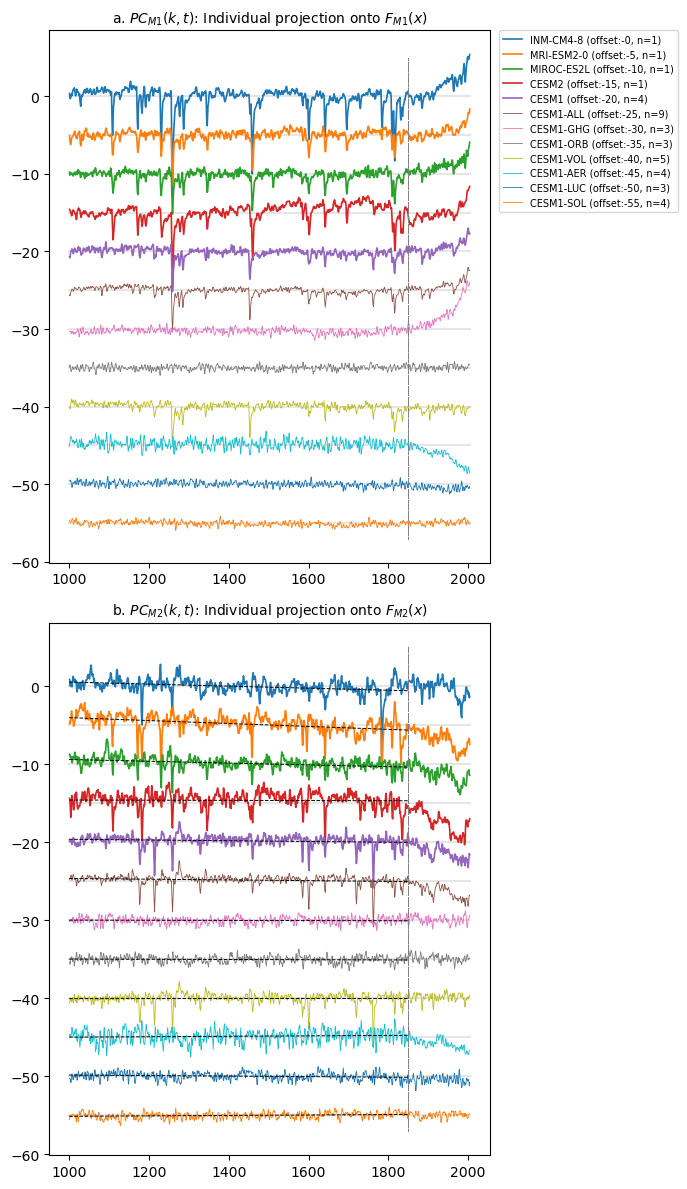

In [19]:
# STEP 12/12

def trendfi(datafi):
    yearsfic = np.arange(860, 1850) 
    print(datafi.shape, yearsfic.shape)
    datafic = datafi
    timefic = xr.DataArray(yearsfic, dims="time", name="time")
    data_arrayfic = xr.DataArray(datafic, dims="time", coords={"time": timefic}, name="data")
    slopefic, interceptfic, _, _, _ = scipy.stats.linregress(yearsfic, data_arrayfic.values)
    trendfic = slopefic * yearsfic + interceptfic
    return trendfic

#varchoi='tas'
#varchoi='pr'
varchoi='both'

if varchoi=='tas':print(YTAS4MULT[0].shape)
if varchoi=='pr': print(YPR4MULT[0].shape)
if varchoi=='both': print(len(YPR4MULT))
if varchoi=='both': print(len(YTAS4MULT))
print(X.shape, stdm, indu)

namessim=['INM-CM4-8', 'MRI-ESM2-0', 'MIROC-ES2L','CESM2','CESM1', 'CESM1-ALL',\
          'CESM1-GHG','CESM1-ORB','CESM1-VOL','CESM1-AER','CESM1-LUC','CESM1-SOL']
lins=['-','-','-','-','-','-',   '-','-','-','-','-','-','-']
linw=[1.2,1.2,1.2,1.2,1.2,0.6,0.6,0.6,0.6,0.6,0.6,0.6]
nbs=['n=1','n=1','n=1','n=1','n=4','n=9','n=3','n=3','n=5','n=4','n=3','n=4']
fig, (axx0,axx1) = plt.subplots(nrows=2,figsize=(7,12))
isk=0
for i in range(0,12,1):
 print(i,YTAS4MULT[i].shape)
 nrol=11; nroa=int((nrol-1)/2)
 nrol=3; nroa=1
 print (nrol, nroa)
 if varchoi=='both':
   if i<5: tpcsF0Proj=tsolverF0.projectField([YTAS4MULT[i],YPR4MULT[i]], neofs=3, eofscaling=1)[:-9]; print(tpcsF0Proj.shape)
   if i>4: tpcsF0Proj=tsolverF0.projectField([YTAS4MULT[i],YPR4MULT[i]], neofs=3, eofscaling=1)
   if i>12:tpcsF0Proj=tsolverF0.projectField([YTAS4MULT[i],YPR4MULT[i]], neofs=3, eofscaling=1)[:-9]
   if i==8: projvol=tsolverF0.projectField([YTAS4MULT[i],YPR4MULT[i]], neofs=3, eofscaling=1)
   if i==9: projaer=tsolverF0.projectField([YTAS4MULT[i],YPR4MULT[i]], neofs=3, eofscaling=1)
 if varchoi=='tas':
  if i<5: tpcsF0Proj=tsolverF0.projectField(YTAS4MULT[i], neofs=3, eofscaling=1)[:-9]; print(tpcsF0Proj.shape)
  if i>4: tpcsF0Proj=tsolverF0.projectField(YTAS4MULT[i], neofs=3, eofscaling=1)
  if i>12:tpcsF0Proj=tsolverF0.projectField(YTAS4MULT[i], neofs=3, eofscaling=1)[:-9]
 if varchoi=='pr':
  if i<5: tpcsF0Proj=tsolverF0.projectField(YPR4MULT[i], neofs=3, eofscaling=1)[:-9]; print(tpcsF0Proj.shape)
  if i>4: tpcsF0Proj=tsolverF0.projectField(YPR4MULT[i], neofs=3, eofscaling=1)
  if i>12:tpcsF0Proj=tsolverF0.projectField(YPR4MULT[i], neofs=3, eofscaling=1)[:-9] 
 if i==0:aa=-9
 tpcsF0Proj= xr.DataArray(tpcsF0Proj,coords={"time": tpcsF0[:aa].time,"numb":list(range(3))},dims=["time","numb"],)
 #
 trend0Proj=trendfi(tpcsF0Proj[10-nroa:1000+nroa,1].rolling(time=nrol,center=True).mean('time')[nroa:-nroa])
 axx0.plot(datait_xrq[150:aa],tpcsF0Proj[150:,0]*0-isk*5,color='0.9',zorder=1)
 axx1.plot(datait_xrq[150:aa],tpcsF0Proj[150:,1]*0-isk*5,color='0.9',zorder=1)
 axx0.plot([datait_xrq[1000],datait_xrq[1000]],[-57,5],linestyle='dashed',markersize=0,color='0.5',linewidth=0.5,zorder=2)
 axx1.plot([datait_xrq[1000],datait_xrq[1000]],[-57,5],linestyle='dashed',markersize=0,color='0.5',linewidth=0.5,zorder=2)
 #axx1.plot(datait_xrq[150:aa],tpcsF0Proj[150:,1]*0-isk*5,color='0.9',zorder=1)
 offs=str(round(isk*5,))
 axx0.plot(datait_xrq[150:aa],tpcsF0Proj[150:,0].rolling(time=nrol,center=True).mean('time')*mult0-isk*5,linestyle=lins[i],markersize=0,linewidth=linw[i],label=namessim[i]+' (offset:-'+offs+', '+nbs[i]+')',zorder=2)
 axx1.plot(datait_xrq[150:aa],tpcsF0Proj[150:,1].rolling(time=nrol,center=True).mean('time')*mult1-isk*5,linestyle=lins[i],markersize=0,linewidth=linw[i],zorder=2)
 axx1.plot(datait_xrq[150:1000],trend0Proj[140:]*mult1-isk*5,linestyle='dashed',markersize=0,color='black',linewidth=0.7,zorder=2)
 #axx1.plot(datait_xrq[150:-9],tpcsF0Proj[150:,1]*0-i)
 axx0.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0,fontsize=7)
 #axx1.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0,fontsize=7)
 if varchoi=='tas':
     axx0.set_title('a. '+r'$PC_{M1}(k,t)$: Individual projection onto '+r'$F_{U1,T}(x) $',fontsize=10)
     axx1.set_title('b. '+r'$PC_{M2}(k,t)$: Individual projection onto '+r'$F_{U2,T}(x) $',fontsize=10)
 if varchoi=='pr':
     axx0.set_title('a. '+r'$PC_{M1}(k,t)$: Individual projection onto '+r'$F_{U1,P}(x) $',fontsize=10)
     axx1.set_title('b. '+r'$PC_{M2}(k,t)$: Individual projection onto '+r'$F_{U2,P}(x) $',fontsize=10)
 if varchoi=='both':
     axx0.set_title('a. '+r'$PC_{M1}(k,t)$: Individual projection onto '+r'$F_{M1}(x) $',fontsize=10)
     axx1.set_title('b. '+r'$PC_{M2}(k,t)$: Individual projection onto '+r'$F_{M2}(x) $',fontsize=10)
 isk=isk+1
fig.tight_layout()
#raise
#if varchoi=='both':
# plt.savefig('FINALREV_proj_YTAS4MULT_YPR4MULT_'+str(nrol)+'_jas_mean_on4models_noACC_REVISIONS3_11ct'+stdm+'_'+Delta+'.png')
# plt.savefig('FINALREV_proj_YTAS4MULT_YPR4MULT_'+str(nrol)+'_jas_mean_on4models_noACC_REVISIONS3_11ct'+stdm+'_'+Delta+'.pdf')
#if varchoi=='tas':
# plt.savefig('FINALREV_proj_YTAS4MULT_'+str(nrol)+'_jas_mean_on4models_noACC_REVISIONS_11ct'+stdm+'.png')
# plt.savefig('FINALREV_proj_YTAS4MULT_'+str(nrol)+'_jas_mean_on4models_noACC_REVISIONS_11ct'+stdm+'.pdf')
#if varchoi=='pr':
# plt.savefig('FINALREV_proj_YPR4MULT_'+str(nrol)+'_jas_mean_on4models_noACC_REVISIONS_11ct'+stdm+'.png')
# plt.savefig('FINALREV_proj_YPR4MULT_'+str(nrol)+'_jas_mean_on4models_noACC_REVISIONS_11ct'+stdm+'.pdf')